<a href="https://colab.research.google.com/github/nitinth001/cartpole-rl/blob/main/q_learning_cartpole_%2B_evaluator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import gymnasium as gym
import tensorflow as tf
import numpy as np
from keras import Model, Input
from keras.layers import Dense

env = gym.make("CartPole-v1")

# Q Network
inp = Input(shape=(4,))
x = Dense(64, activation="relu")(inp)
x = Dense(32, activation="relu")(x)
out = Dense(2, activation="linear")(x)

q_net = Model(inp, out)

ALPHA = 0.001
GAMMA = 0.99
EPSILON = 1.0
EPSILON_DECAY = 0.995
EPSILON_MIN = 0.01
EPISODES = 300


def policy(state, explore):
    q_values = q_net(state)
    action = tf.argmax(q_values[0]).numpy()

    if np.random.rand() < explore:
        action = np.random.randint(2)

    return action


for episode in range(EPISODES):

    state, _ = env.reset()
    state = tf.convert_to_tensor([state], dtype=tf.float32)

    done = False
    total_reward = 0
    length = 0

    while not done:

        action = policy(state, EPSILON)

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        next_state_tf = tf.convert_to_tensor([next_state], dtype=tf.float32)

        # Q-learning target
        target = reward + GAMMA * tf.reduce_max(q_net(next_state_tf))

        if done:
            target = reward

        with tf.GradientTape() as tape:
            q_values = q_net(state)
            q_value = q_values[0][action]

        grads = tape.gradient(q_value, q_net.trainable_variables)

        delta = target - q_value

        for i in range(len(grads)):
            q_net.trainable_variables[i].assign_add(ALPHA * delta * grads[i])

        state = next_state_tf

        total_reward += reward
        length += 1

    EPSILON = max(EPSILON_MIN, EPSILON * EPSILON_DECAY)

    print("Episode:", episode,
          "Length:", length,
          "Reward:", total_reward,
          "Epsilon:", round(EPSILON,3))

env.close()

Episode: 0 Length: 13 Reward: 13.0 Epsilon: 0.995
Episode: 1 Length: 24 Reward: 24.0 Epsilon: 0.99
Episode: 2 Length: 14 Reward: 14.0 Epsilon: 0.985
Episode: 3 Length: 43 Reward: 43.0 Epsilon: 0.98
Episode: 4 Length: 12 Reward: 12.0 Epsilon: 0.975
Episode: 5 Length: 19 Reward: 19.0 Epsilon: 0.97
Episode: 6 Length: 26 Reward: 26.0 Epsilon: 0.966
Episode: 7 Length: 11 Reward: 11.0 Epsilon: 0.961
Episode: 8 Length: 28 Reward: 28.0 Epsilon: 0.956
Episode: 9 Length: 39 Reward: 39.0 Epsilon: 0.951
Episode: 10 Length: 27 Reward: 27.0 Epsilon: 0.946
Episode: 11 Length: 15 Reward: 15.0 Epsilon: 0.942
Episode: 12 Length: 22 Reward: 22.0 Epsilon: 0.937
Episode: 13 Length: 14 Reward: 14.0 Epsilon: 0.932
Episode: 14 Length: 18 Reward: 18.0 Epsilon: 0.928
Episode: 15 Length: 12 Reward: 12.0 Epsilon: 0.923
Episode: 16 Length: 15 Reward: 15.0 Epsilon: 0.918
Episode: 17 Length: 16 Reward: 16.0 Epsilon: 0.914
Episode: 18 Length: 12 Reward: 12.0 Epsilon: 0.909
Episode: 19 Length: 21 Reward: 21.0 Epsilon:

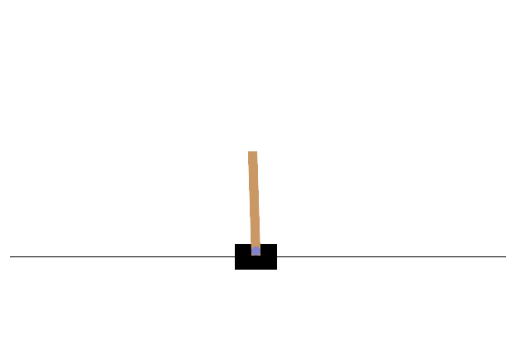

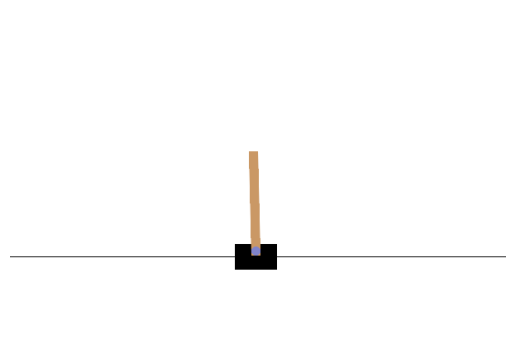

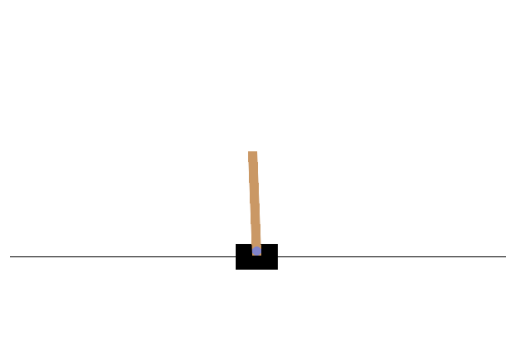

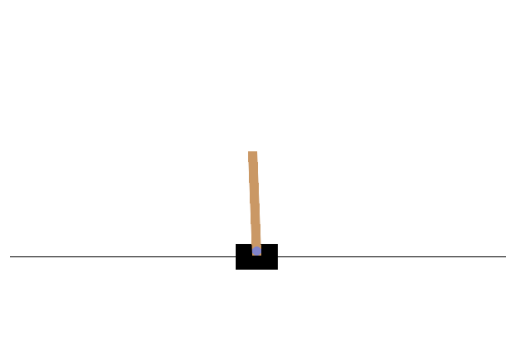

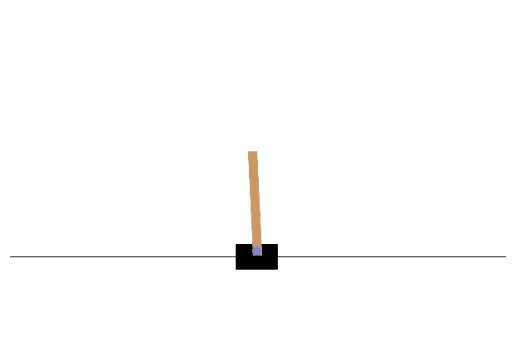

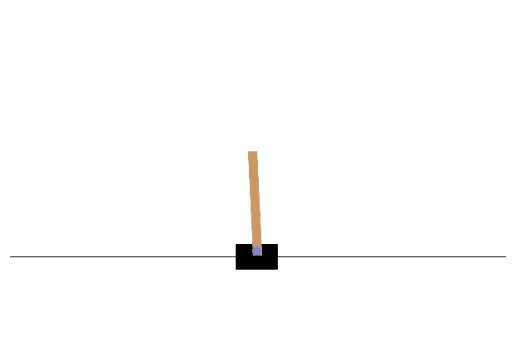

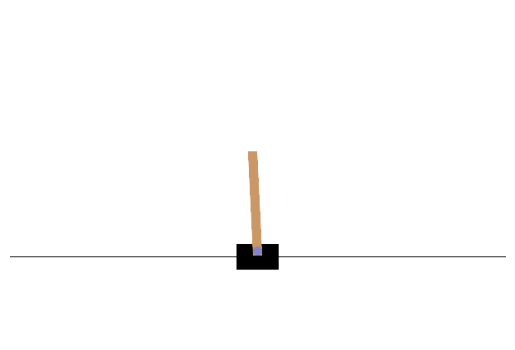

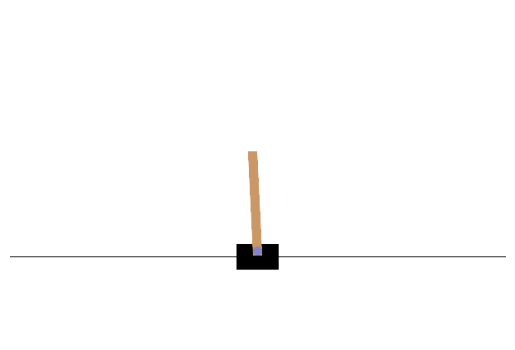

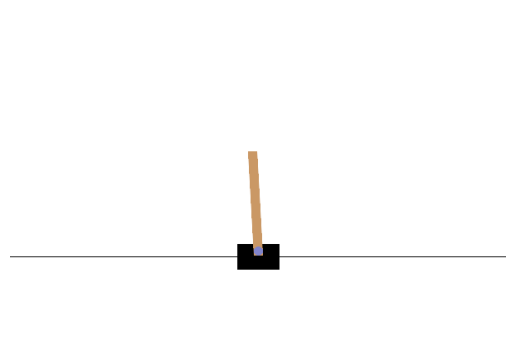

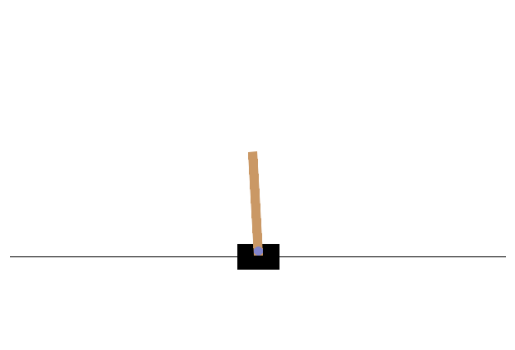

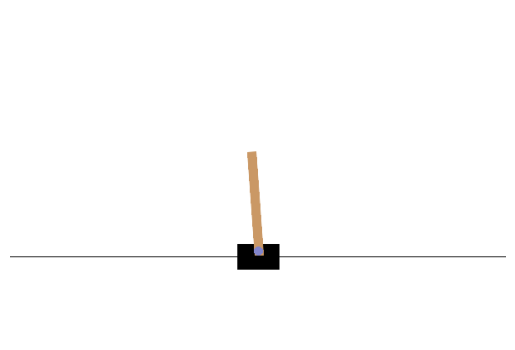

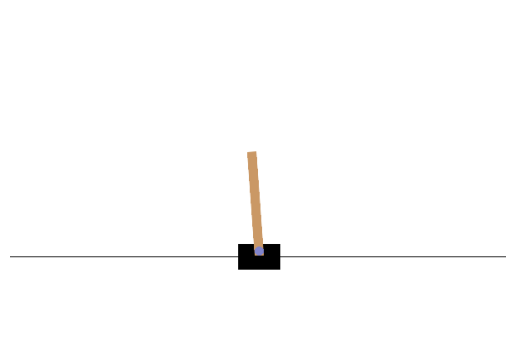

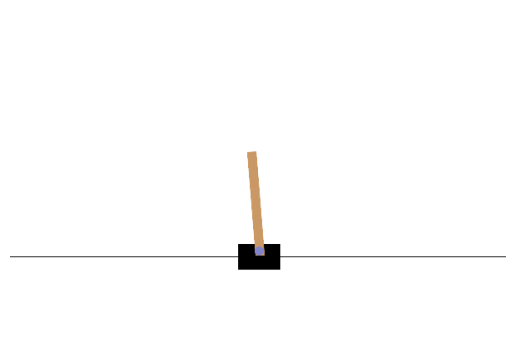

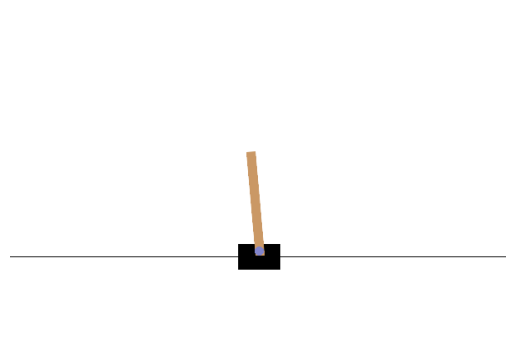

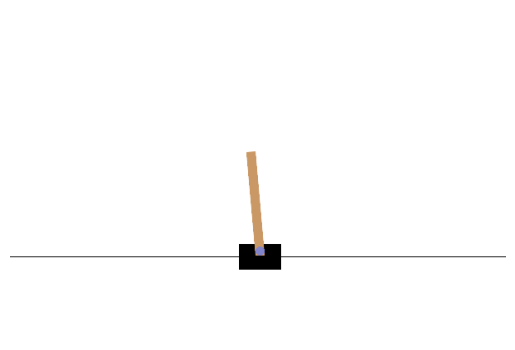

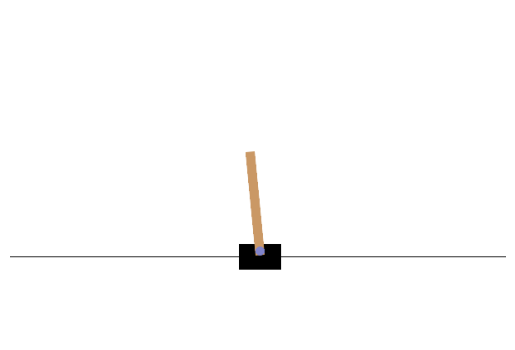

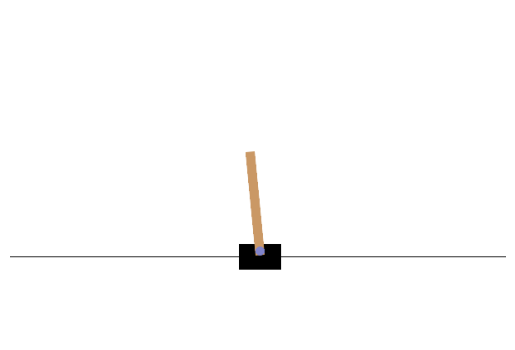

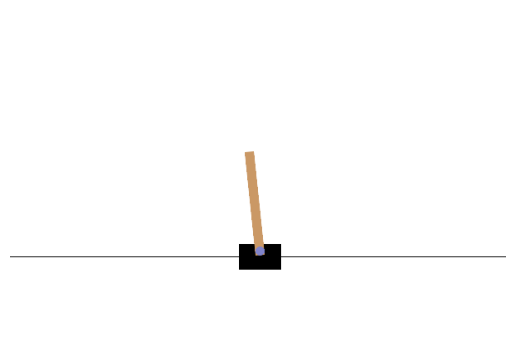

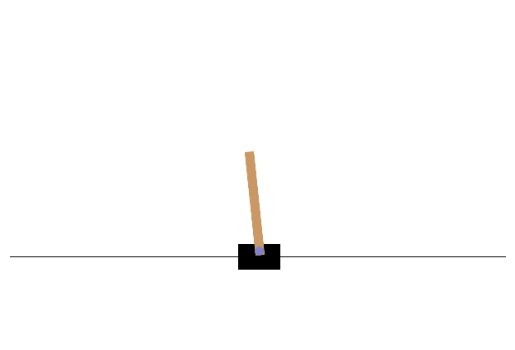

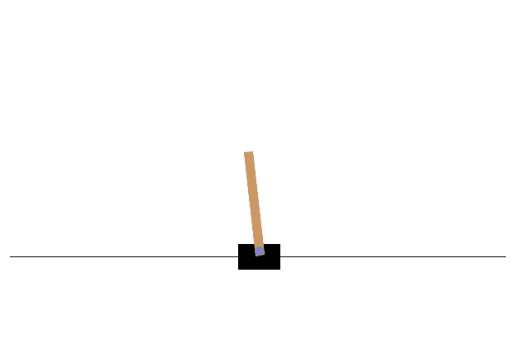

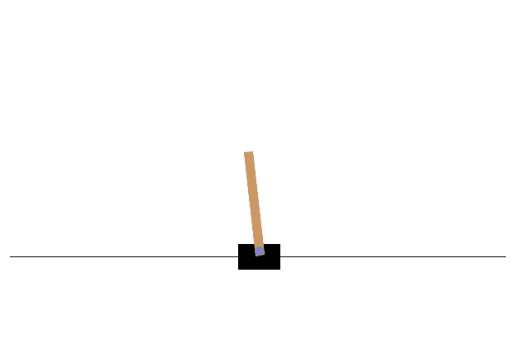

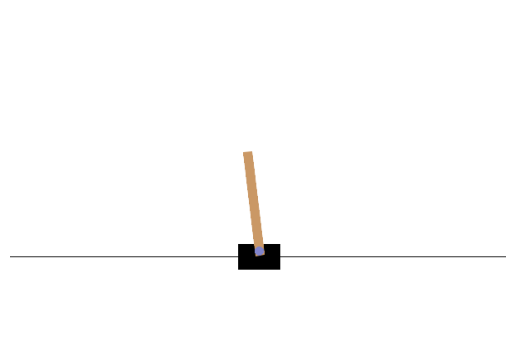

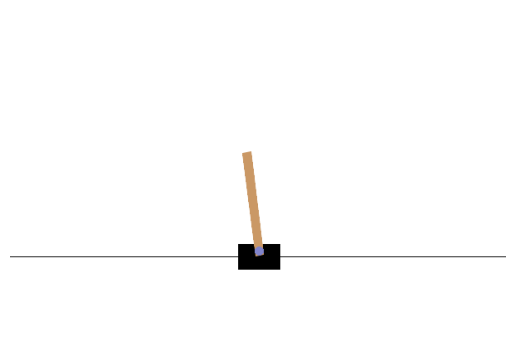

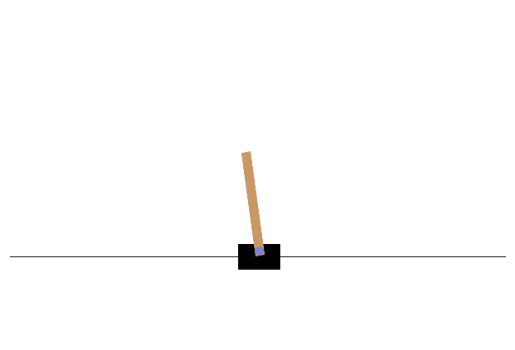

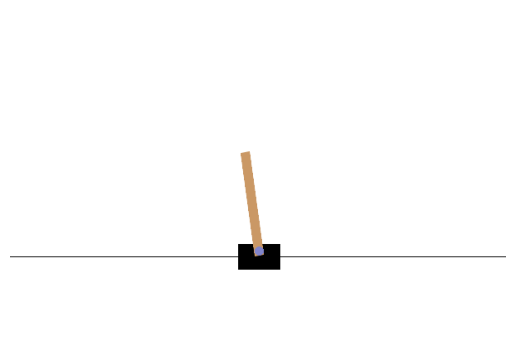

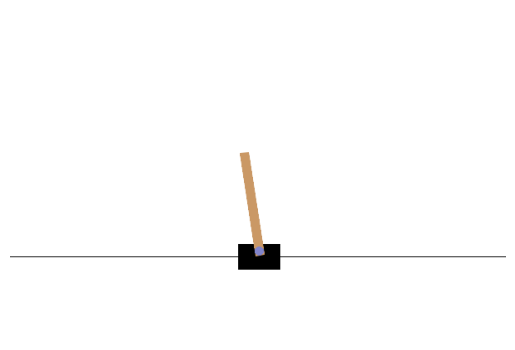

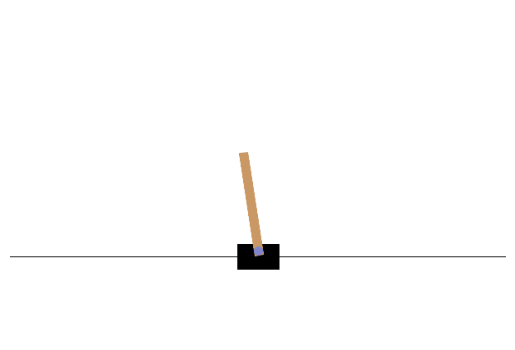

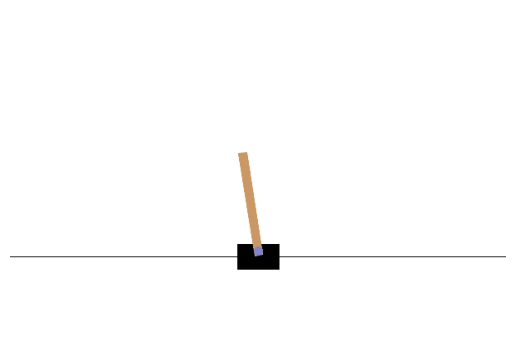

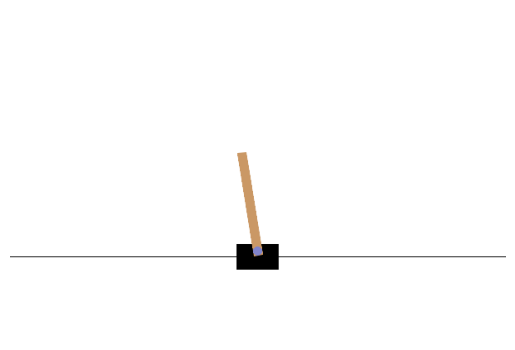

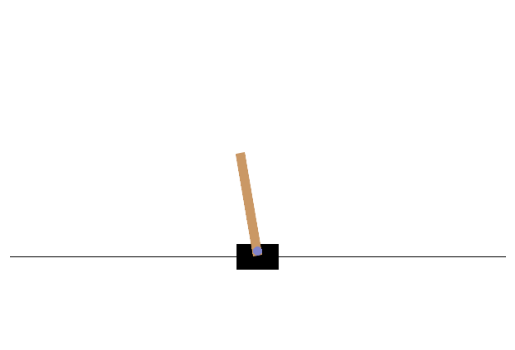

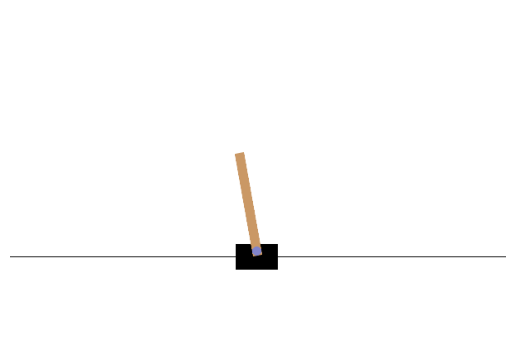

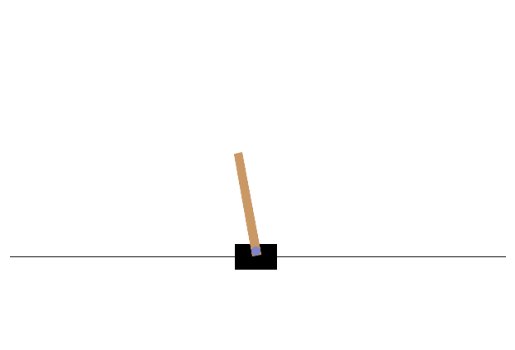

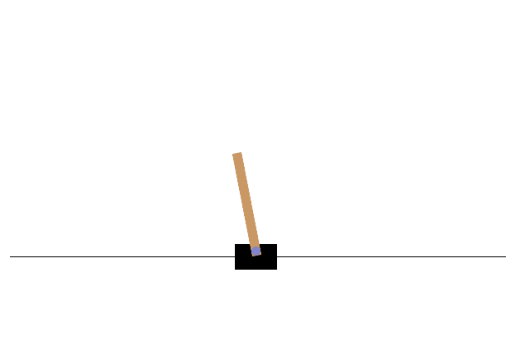

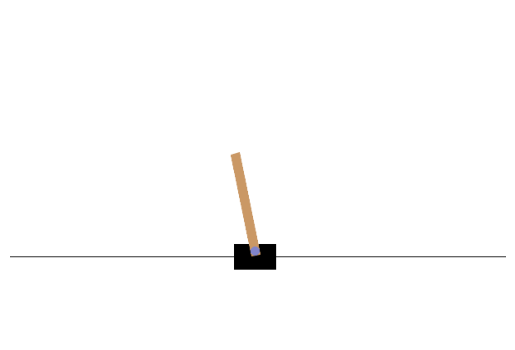

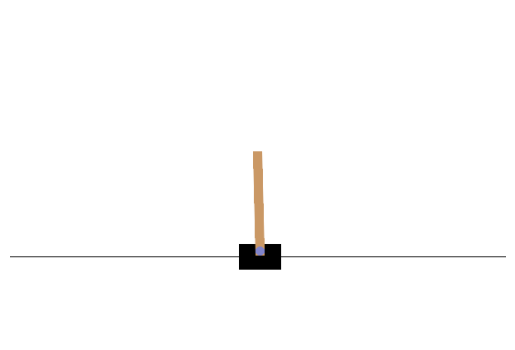

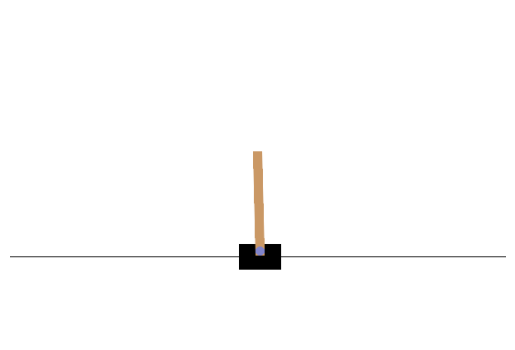

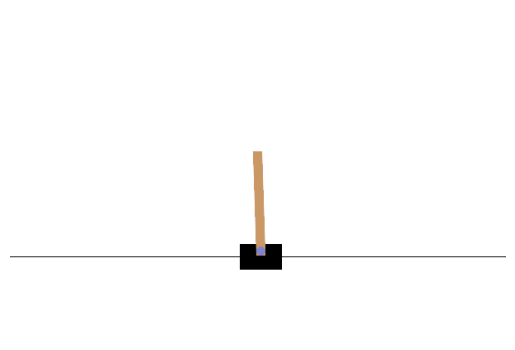

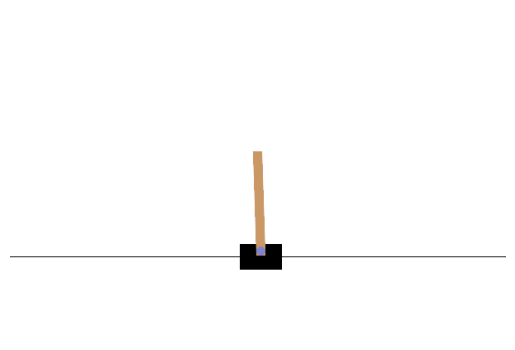

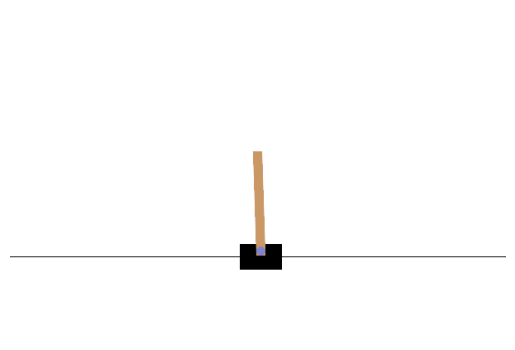

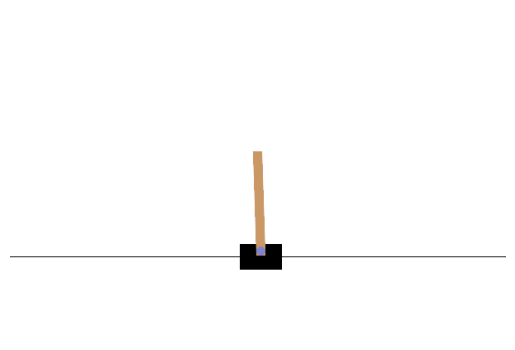

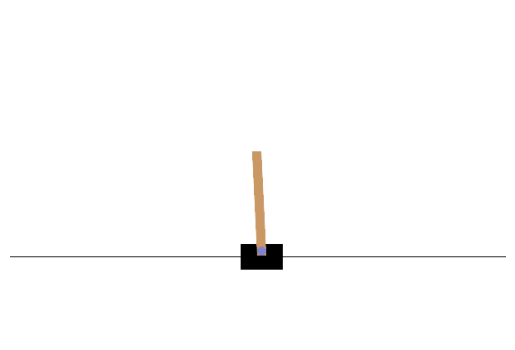

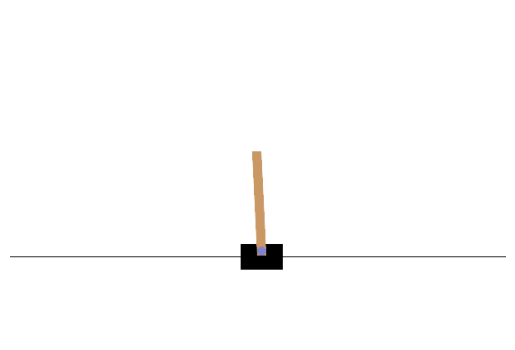

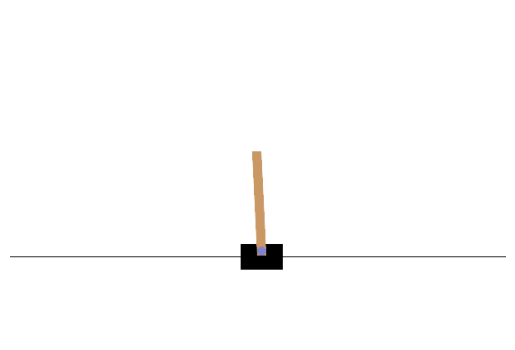

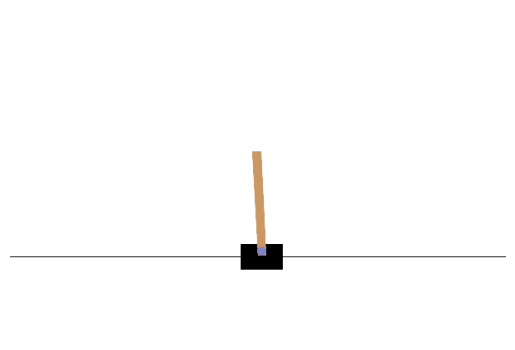

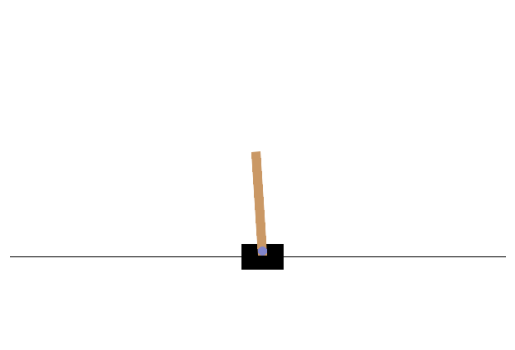

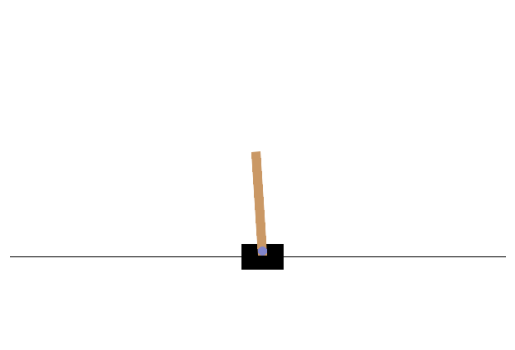

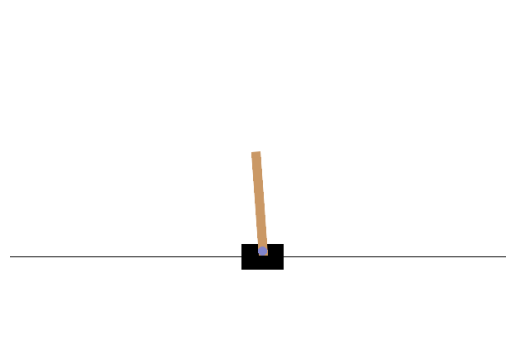

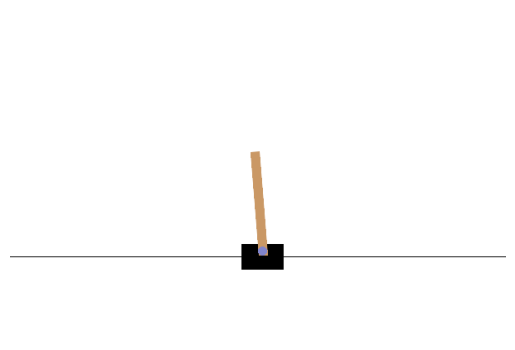

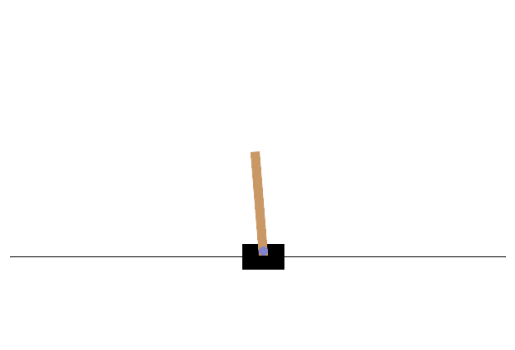

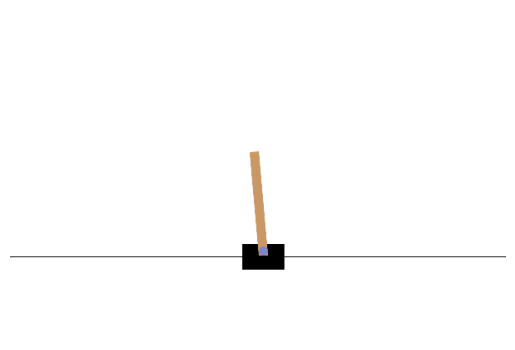

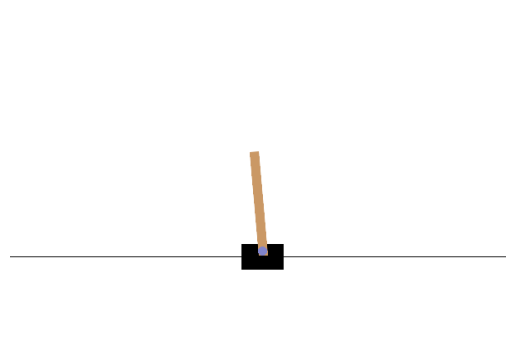

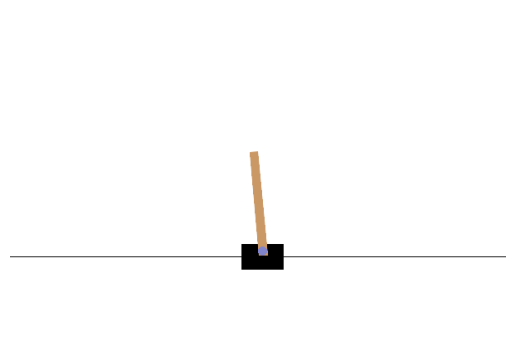

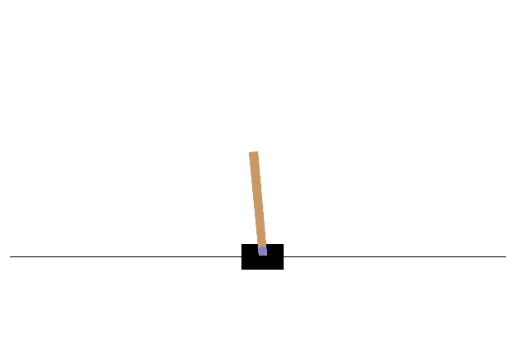

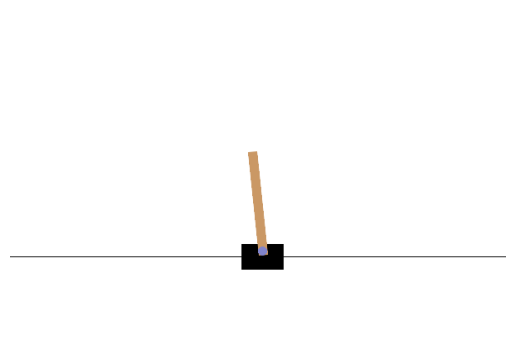

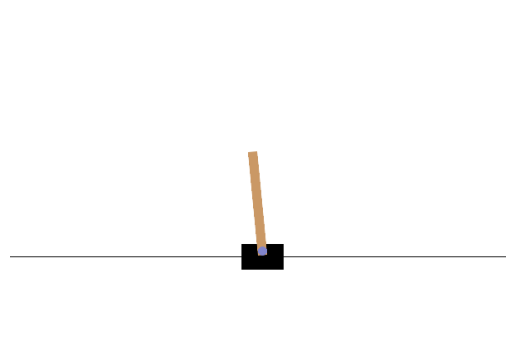

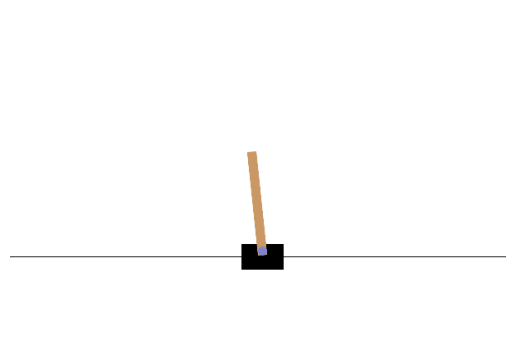

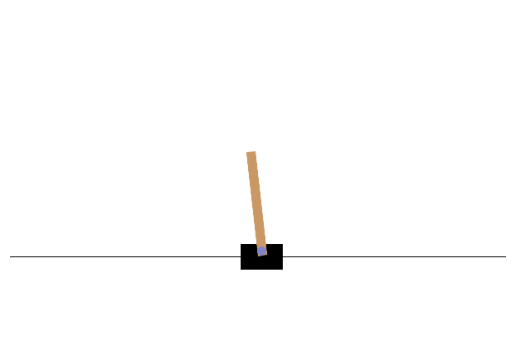

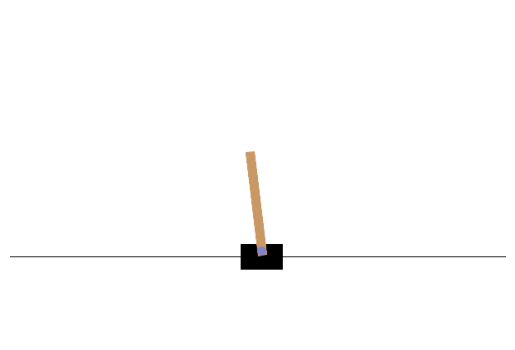

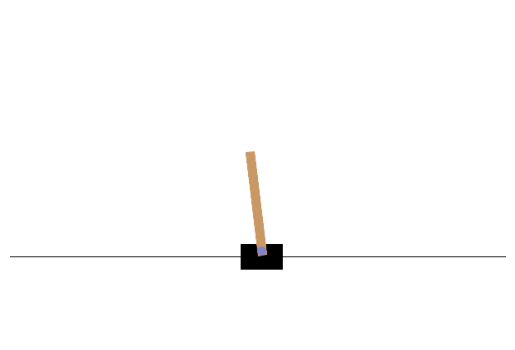

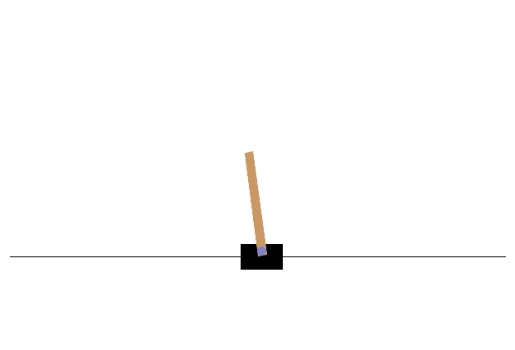

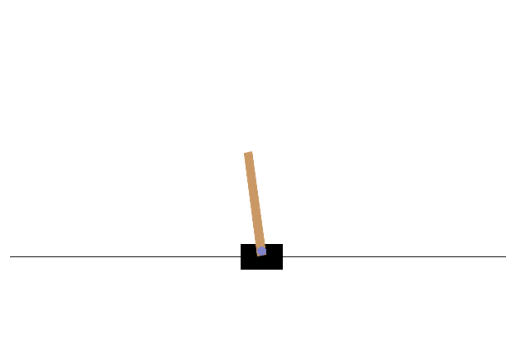

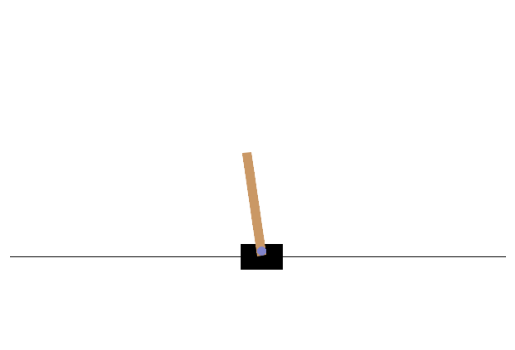

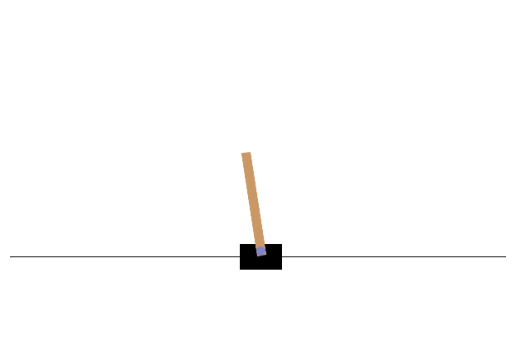

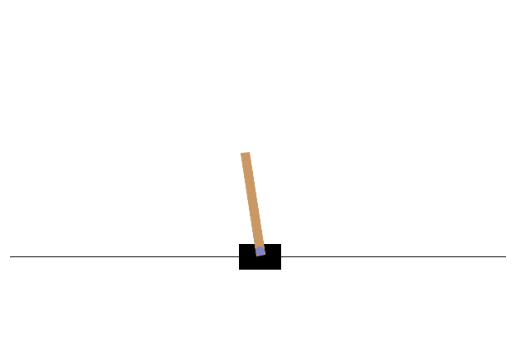

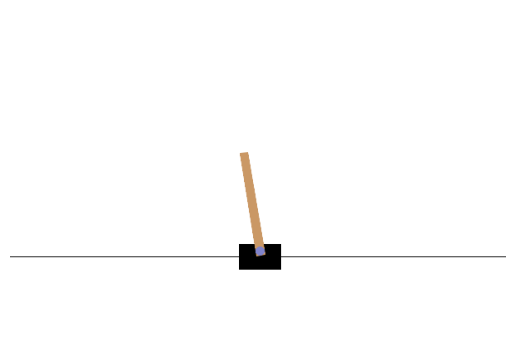

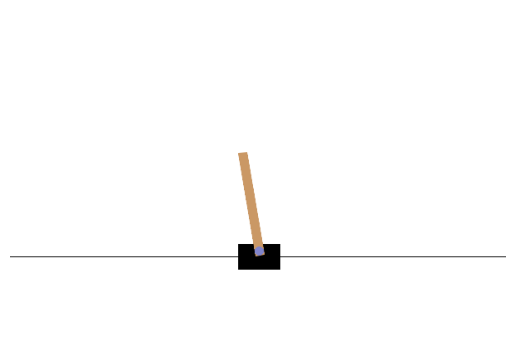

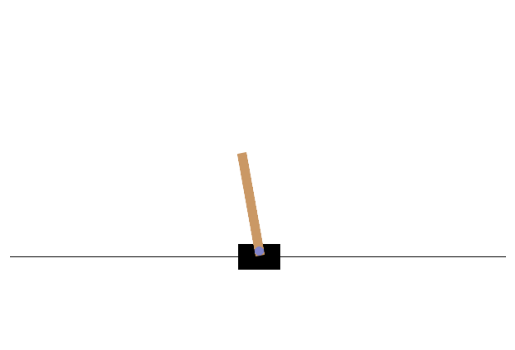

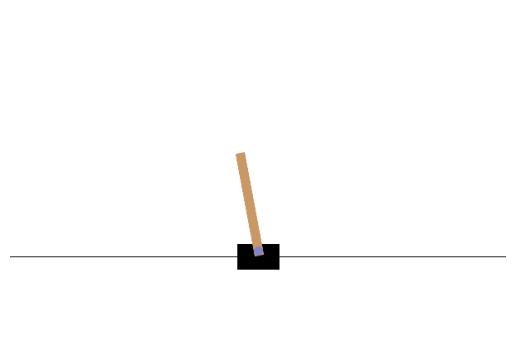

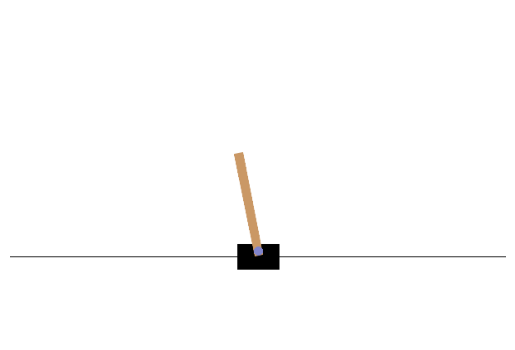

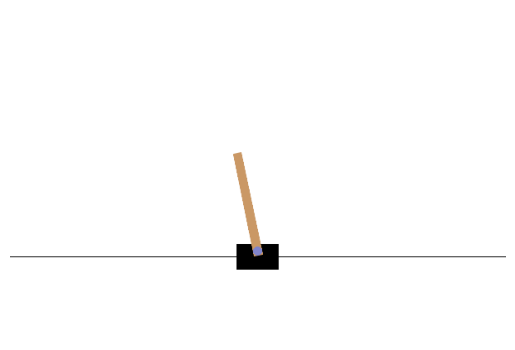

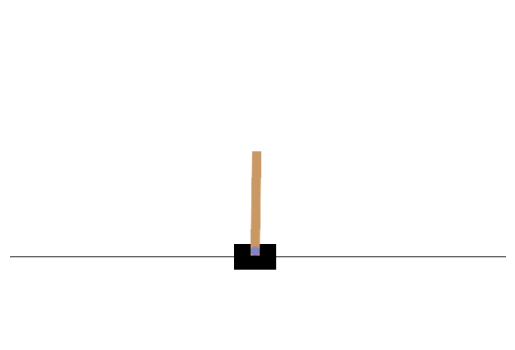

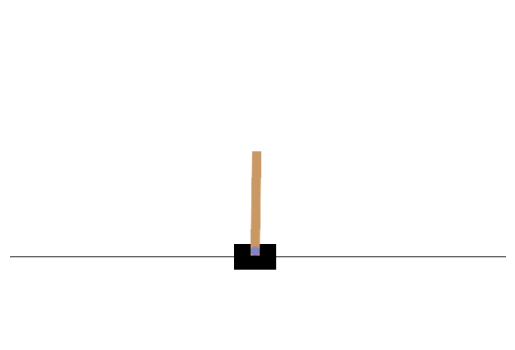

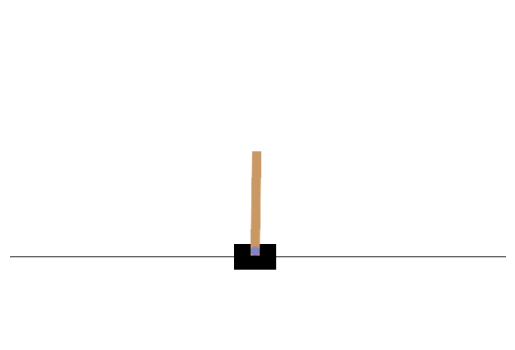

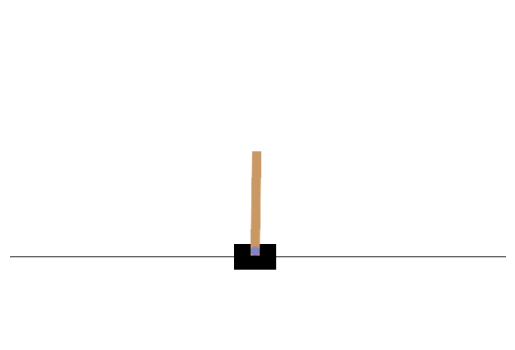

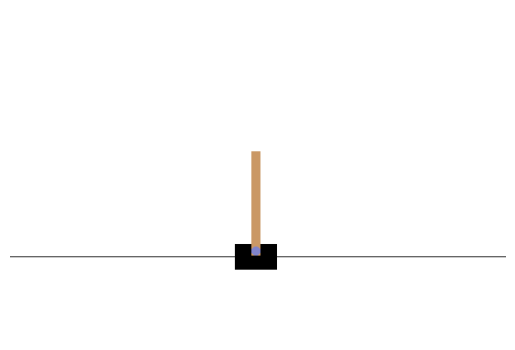

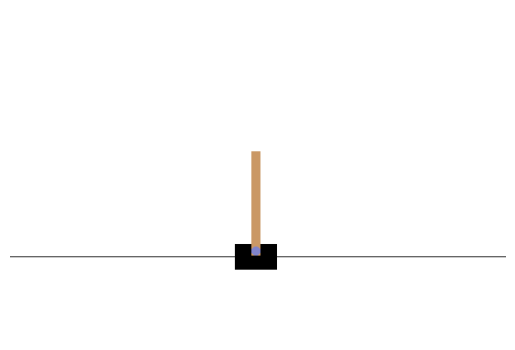

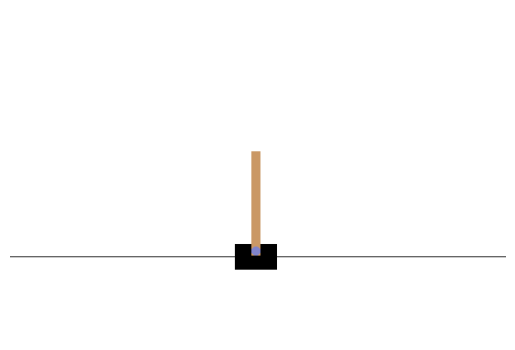

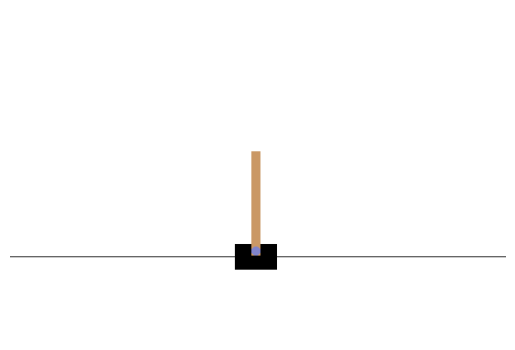

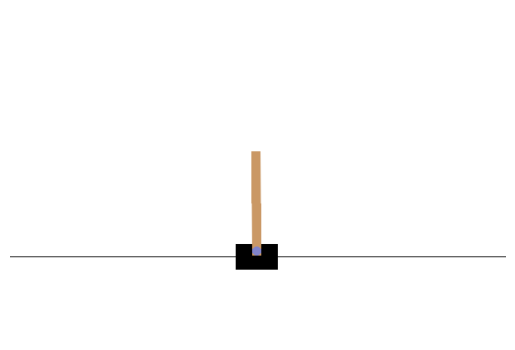

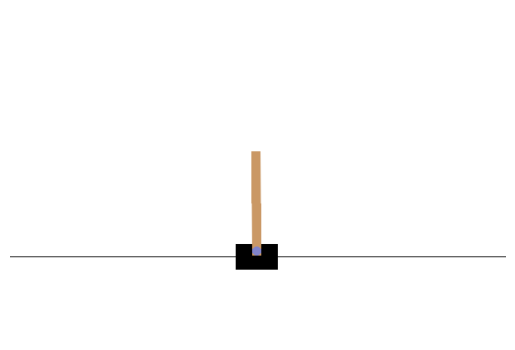

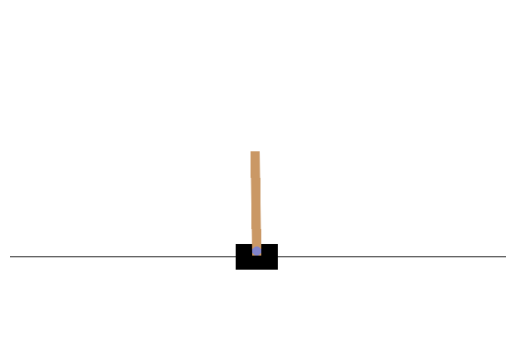

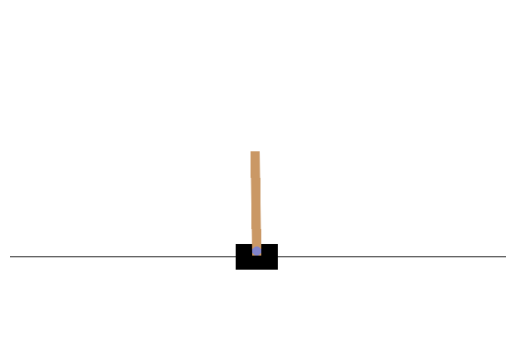

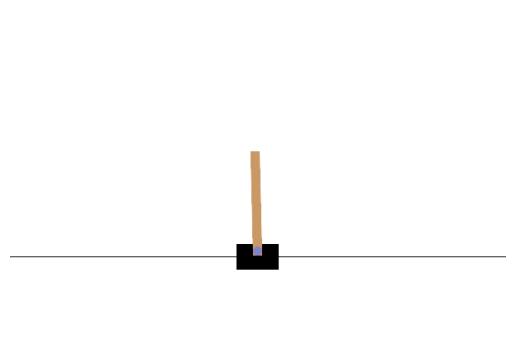

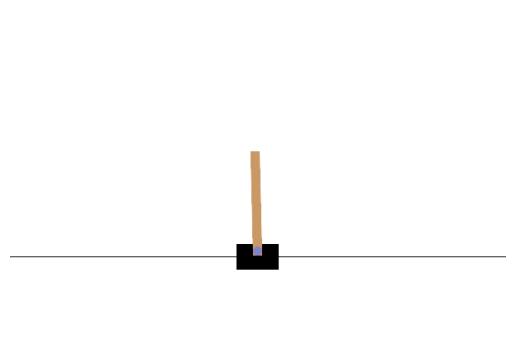

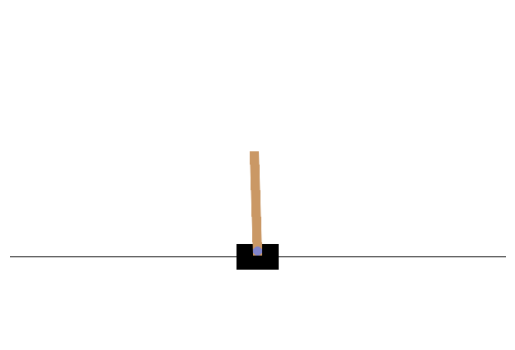

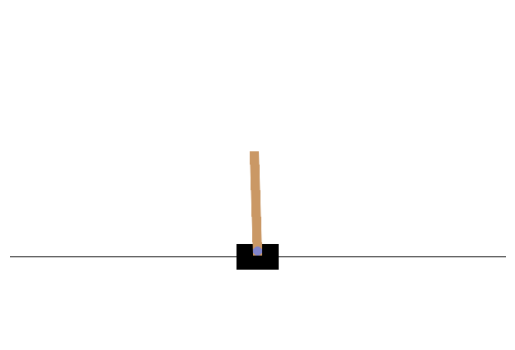

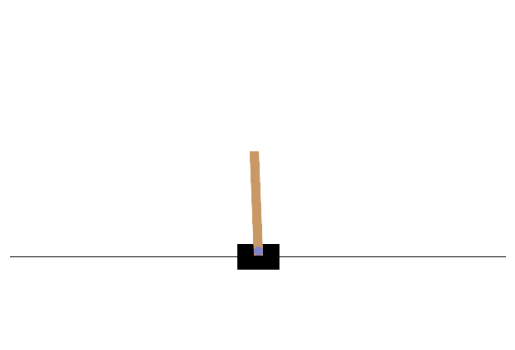

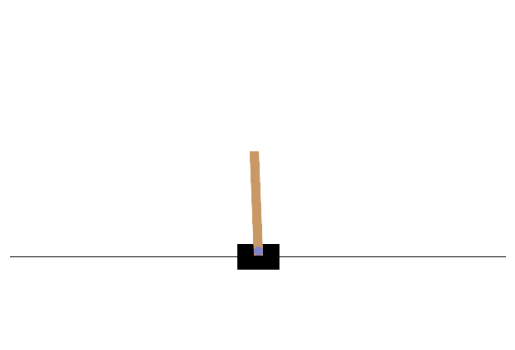

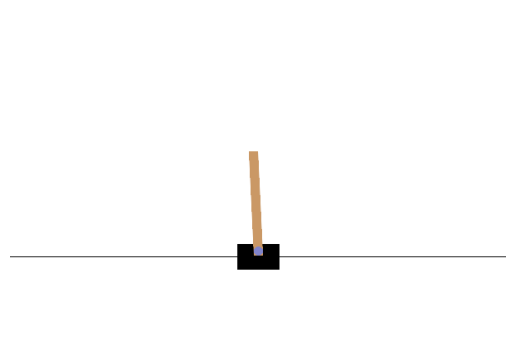

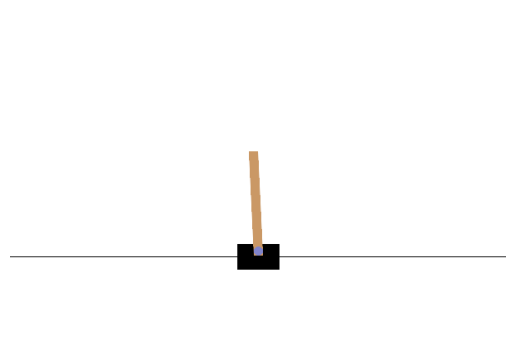

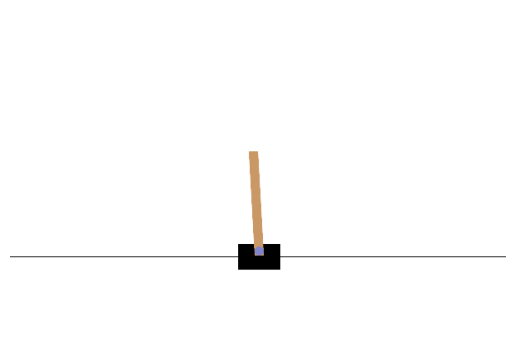

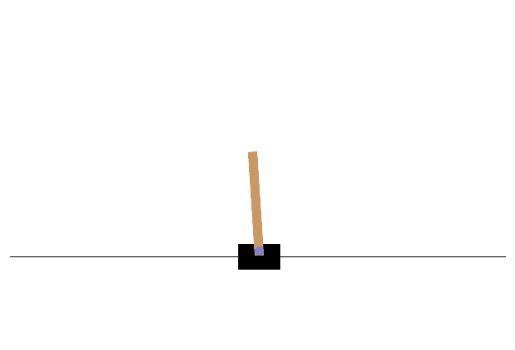

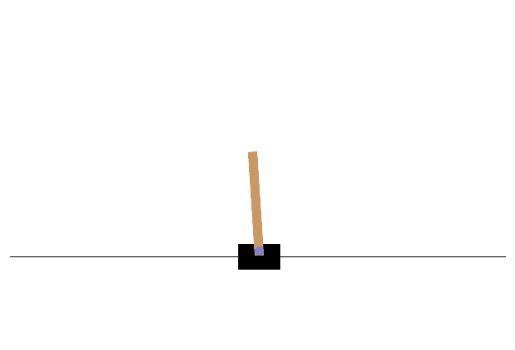

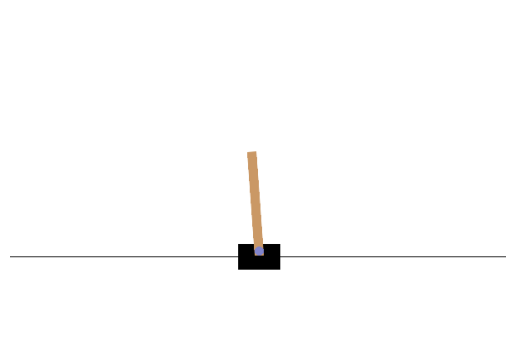

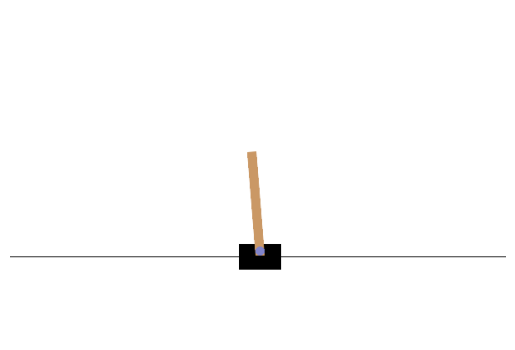

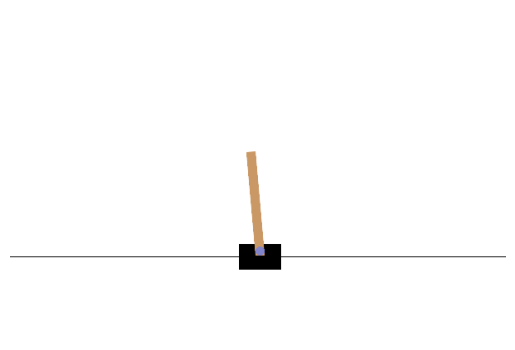

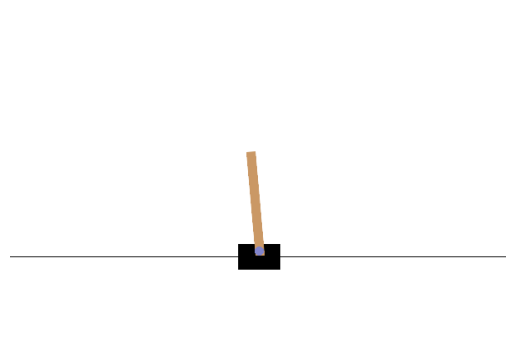

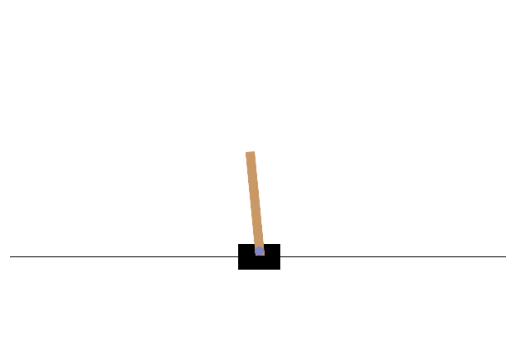

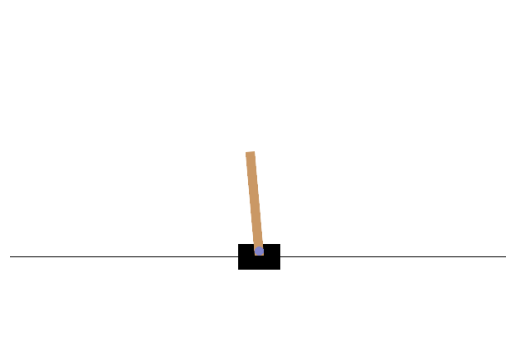

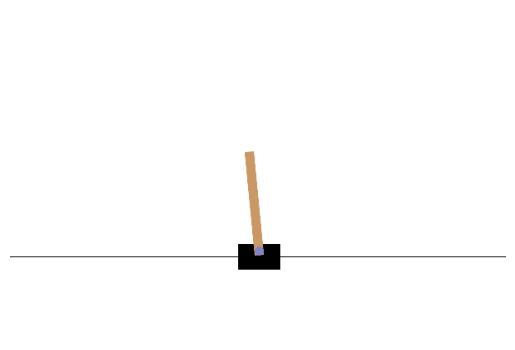

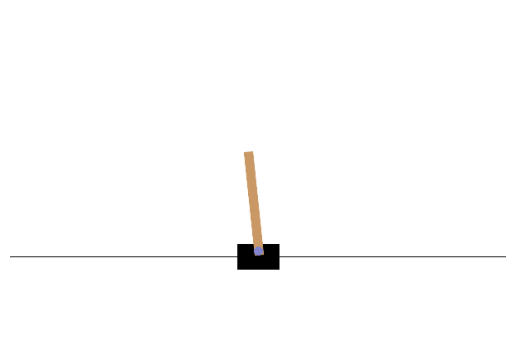

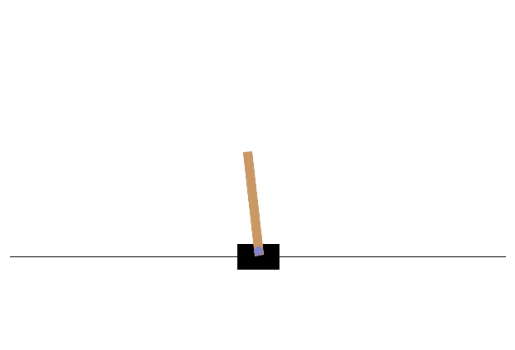

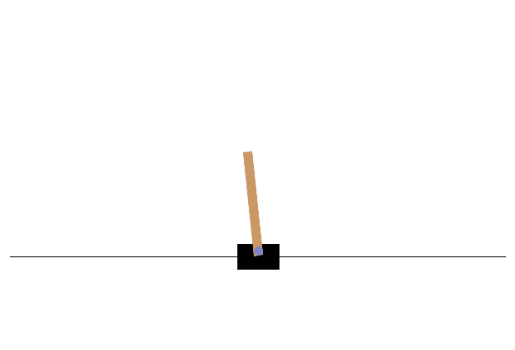

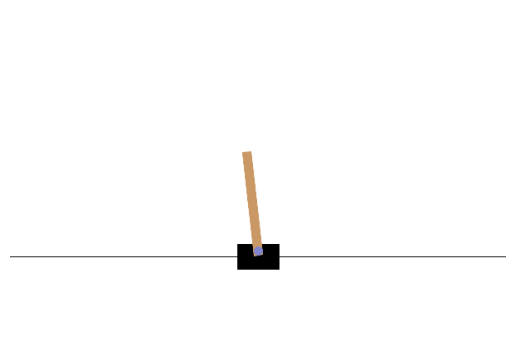

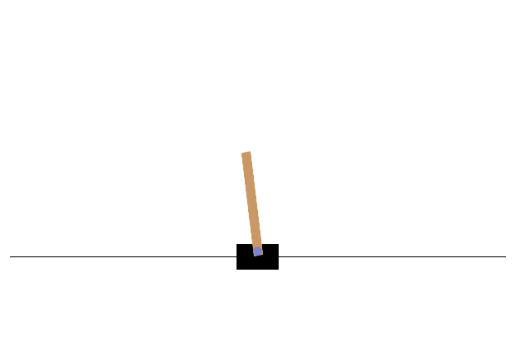

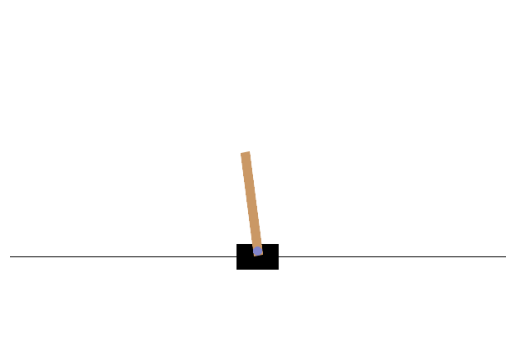

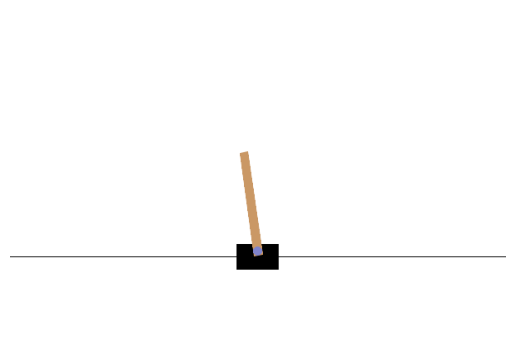

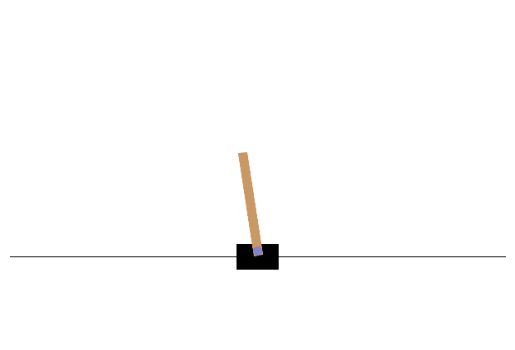

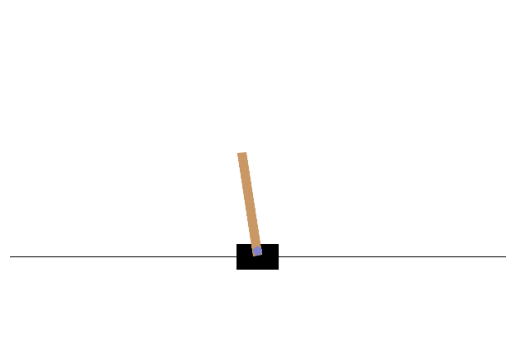

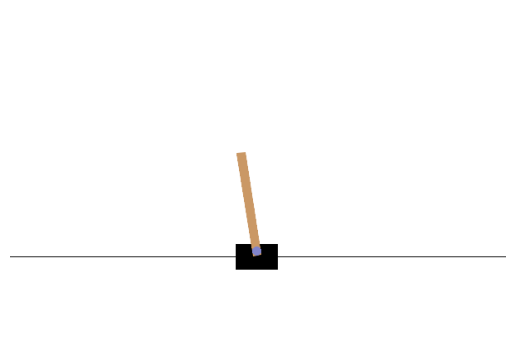

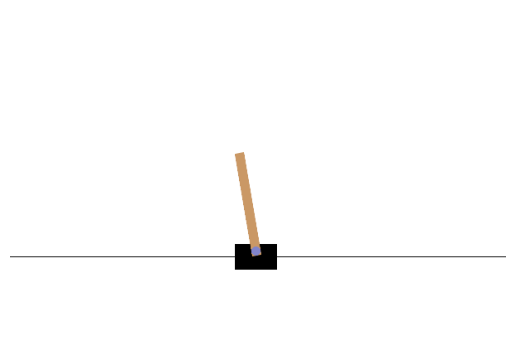

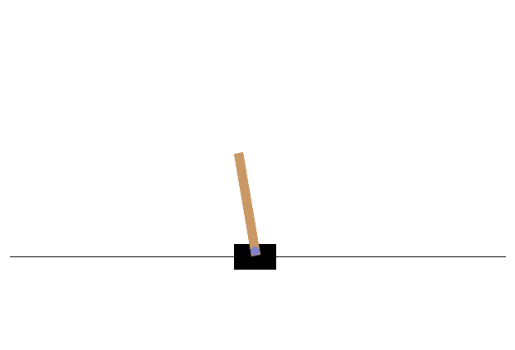

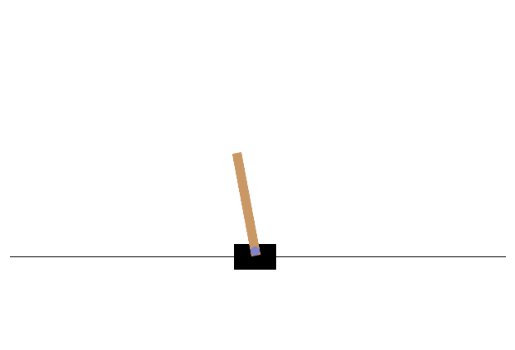

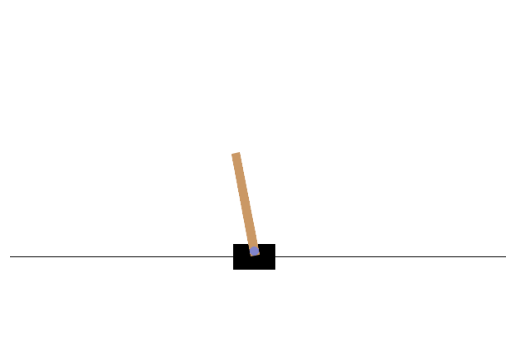

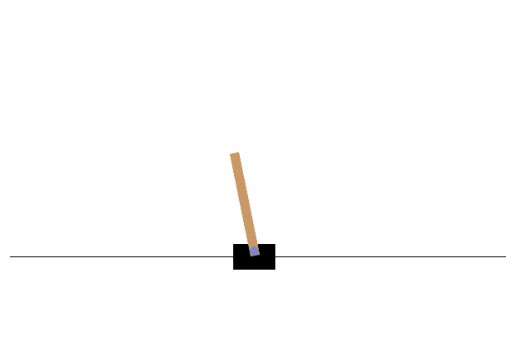

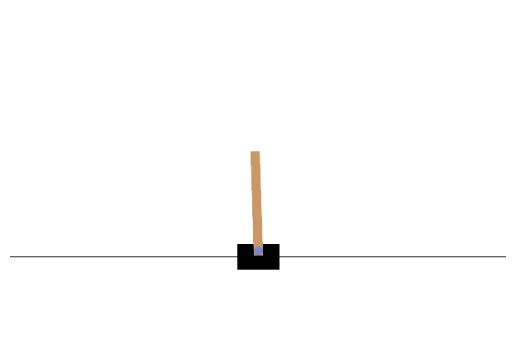

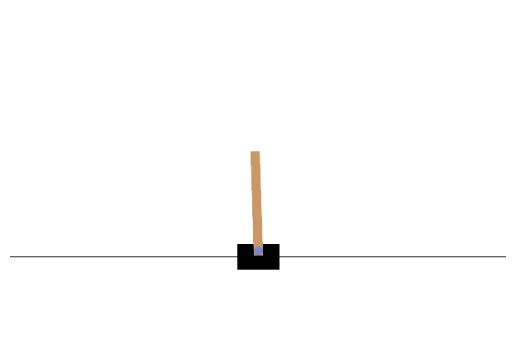

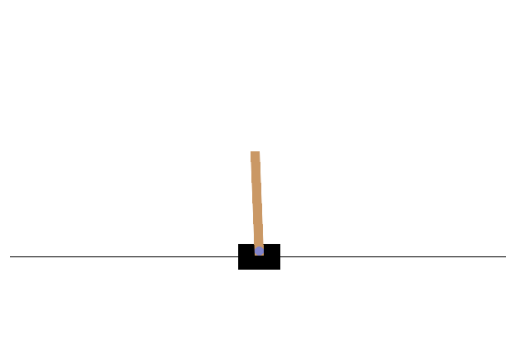

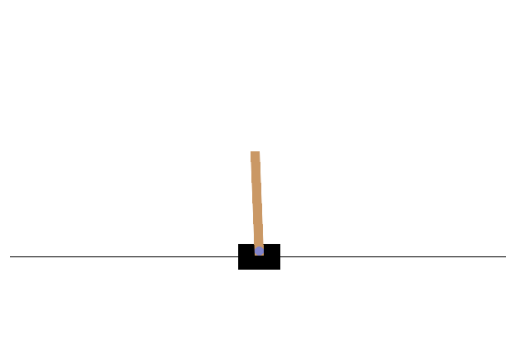

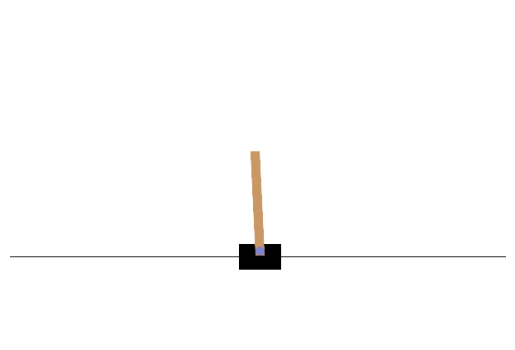

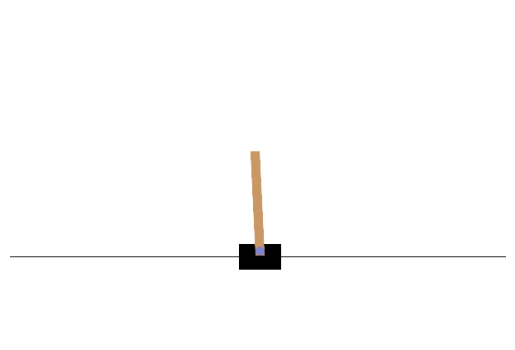

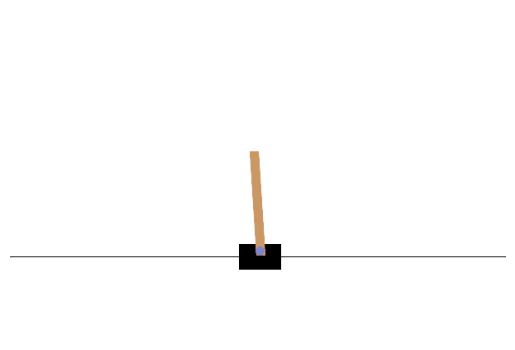

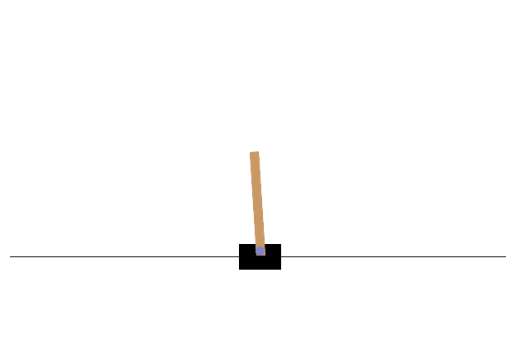

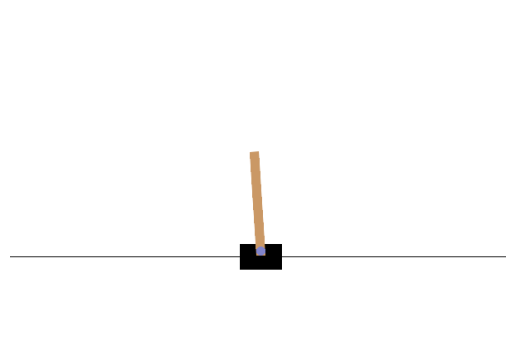

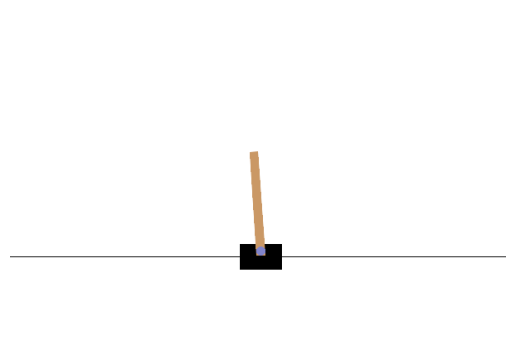

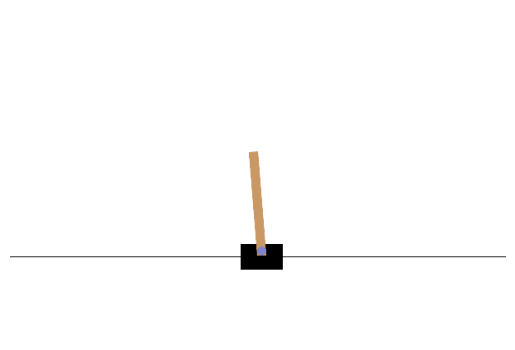

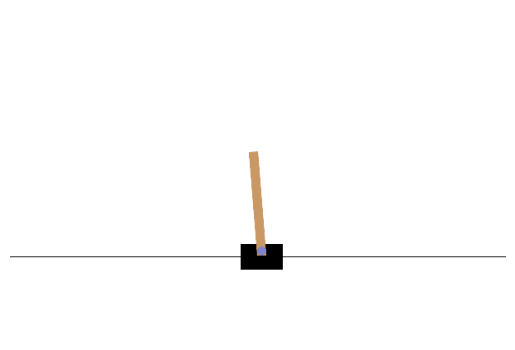

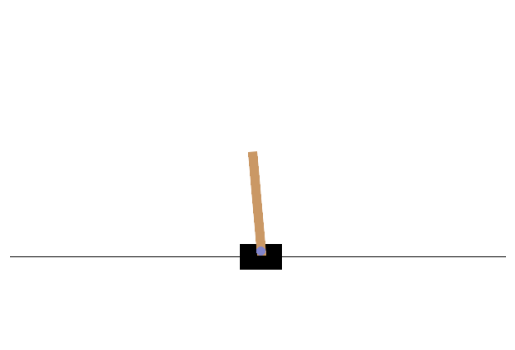

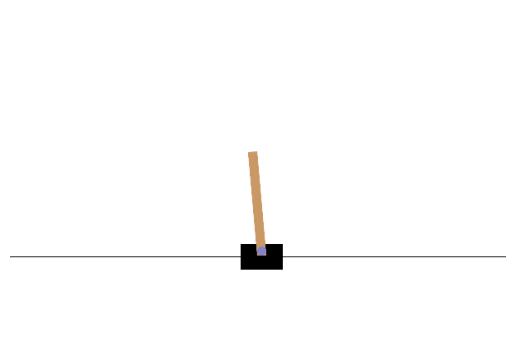

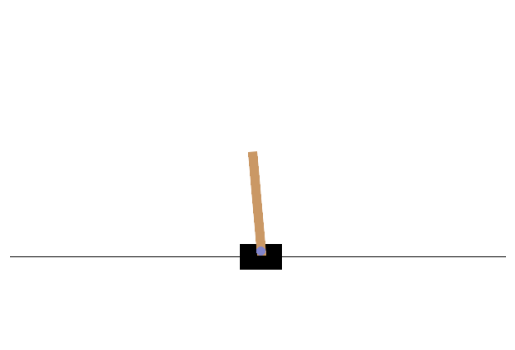

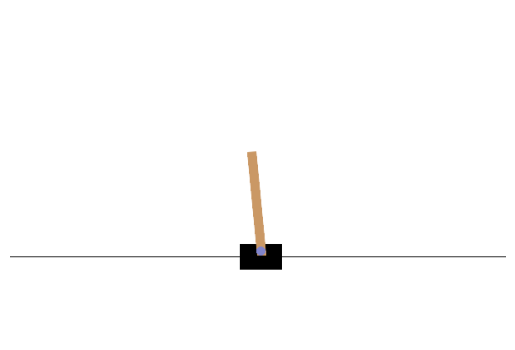

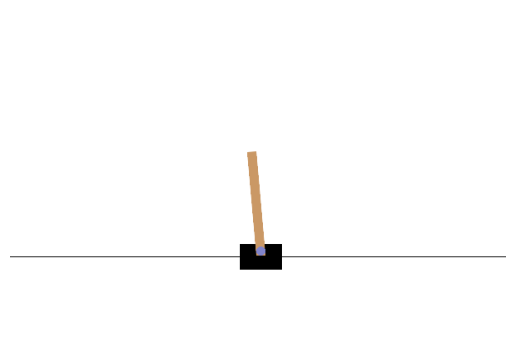

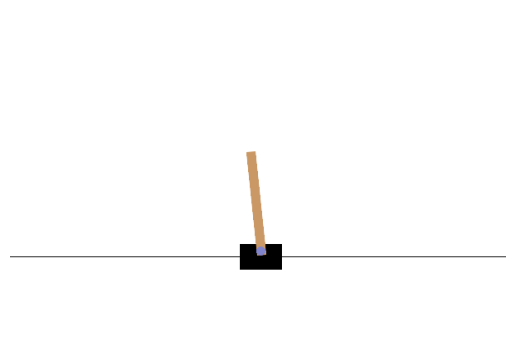

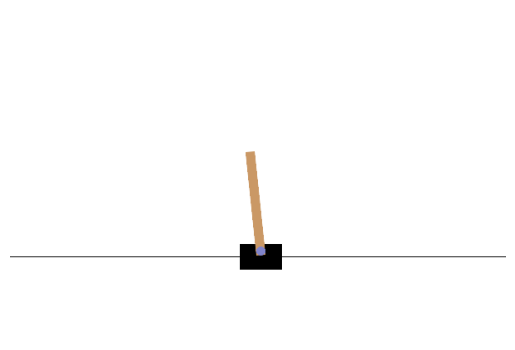

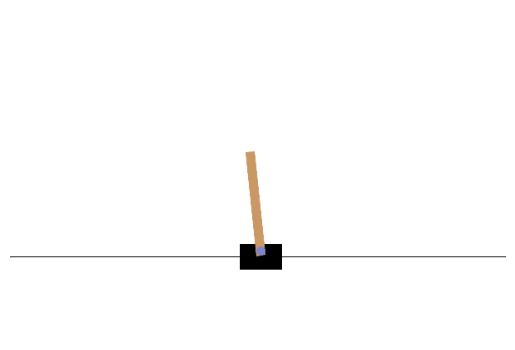

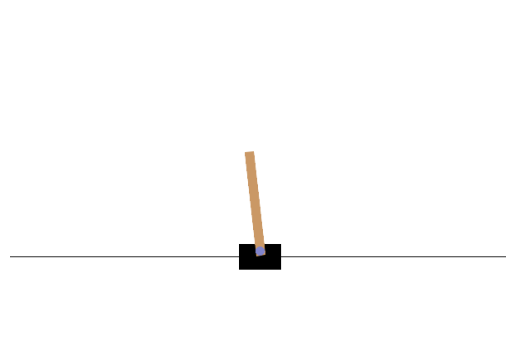

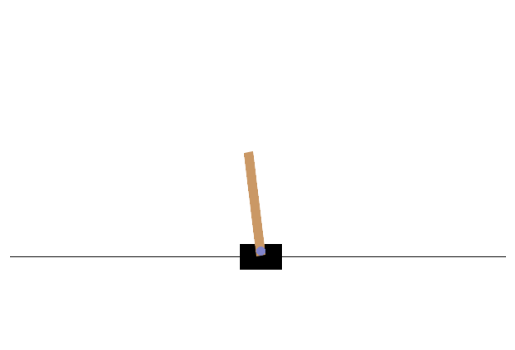

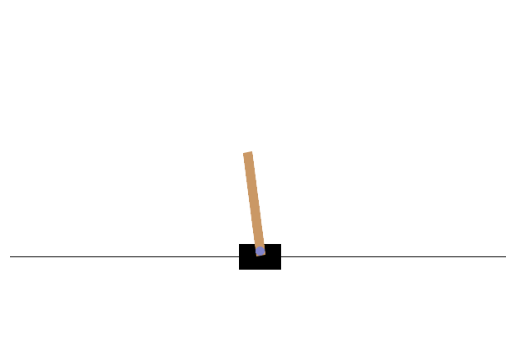

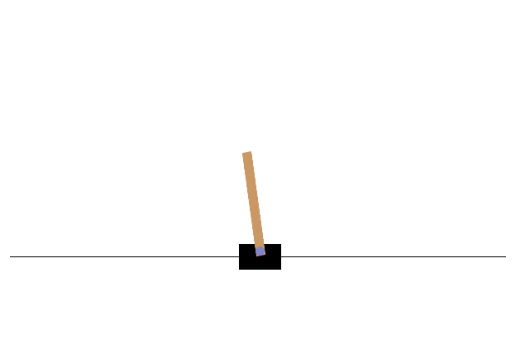

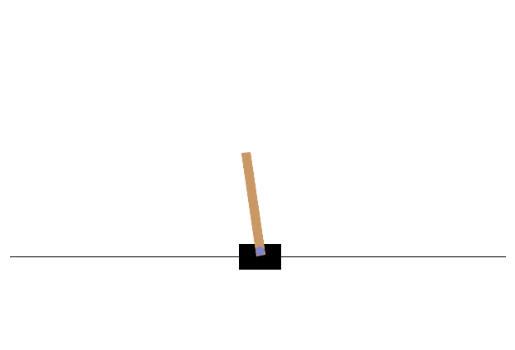

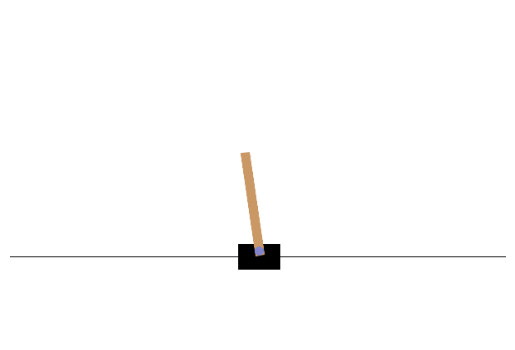

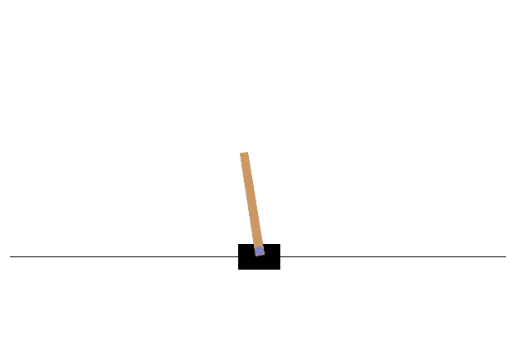

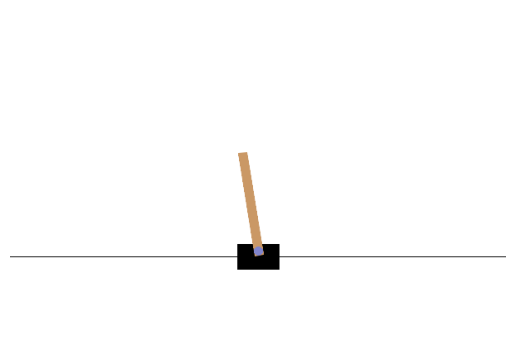

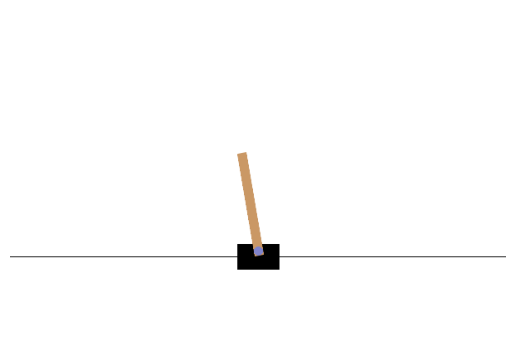

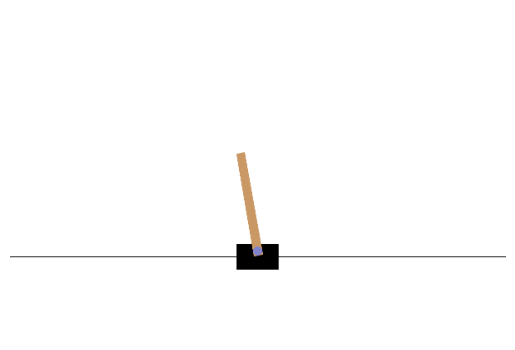

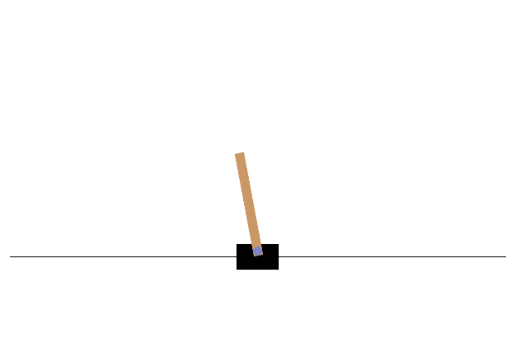

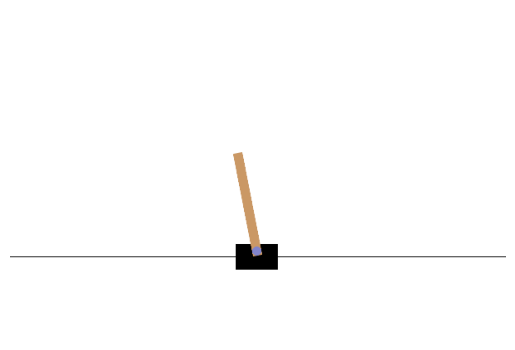

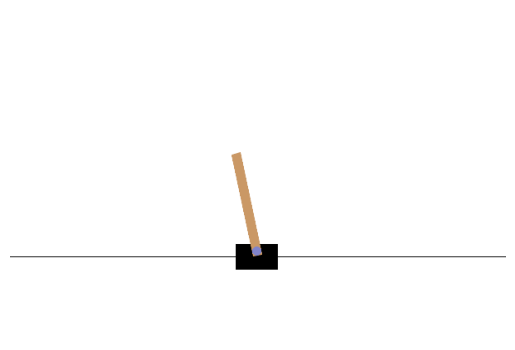

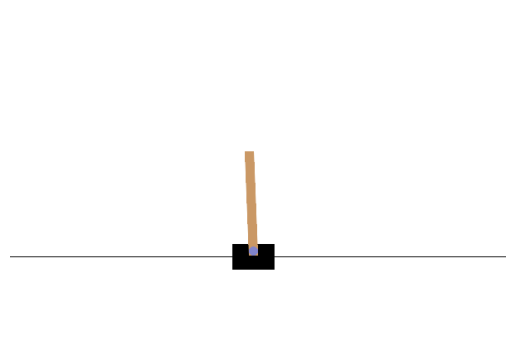

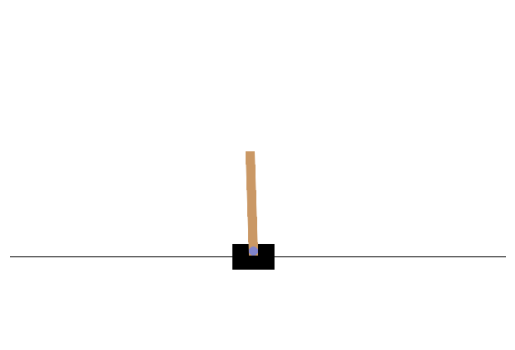

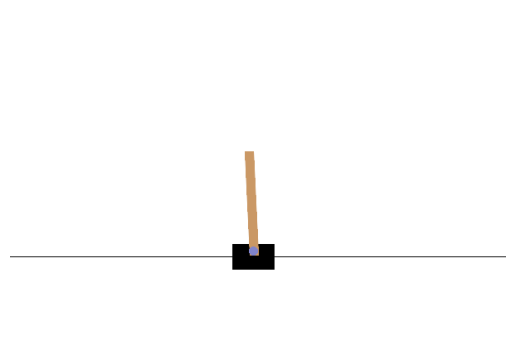

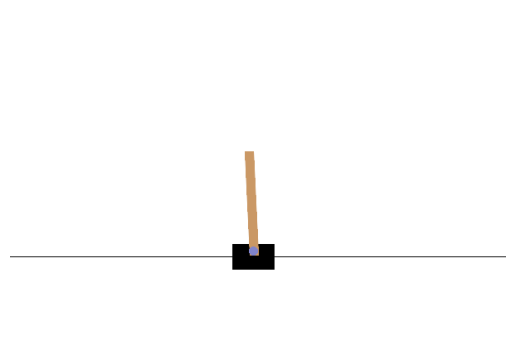

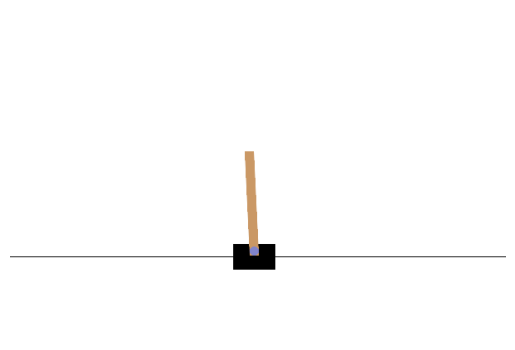

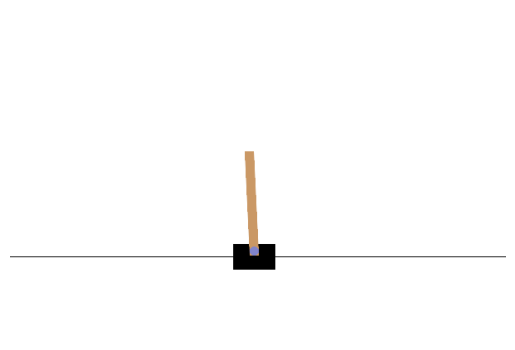

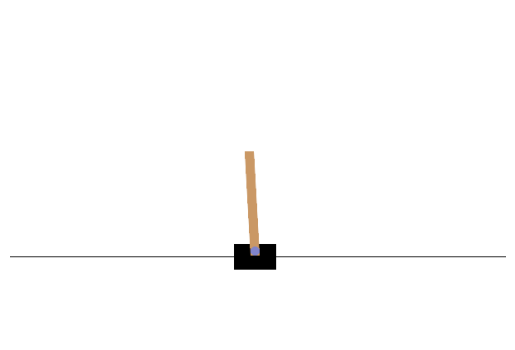

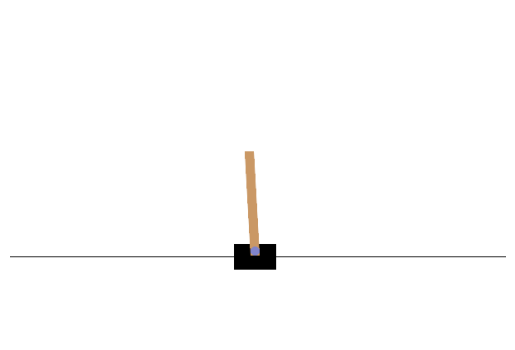

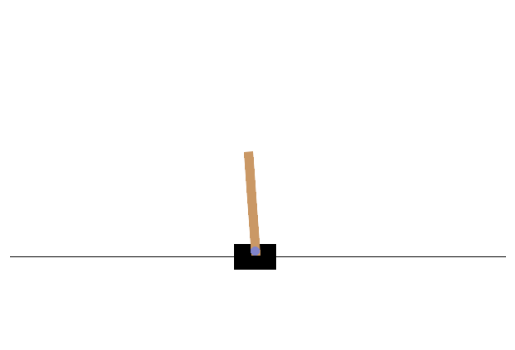

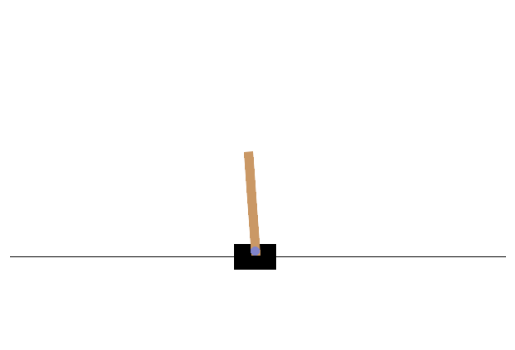

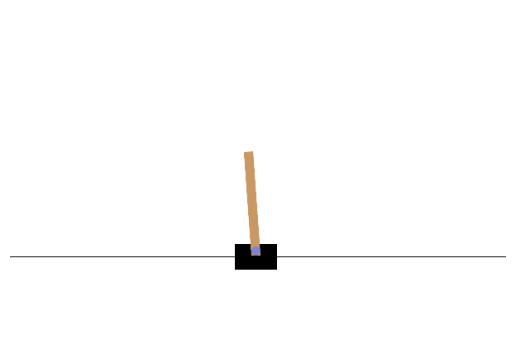

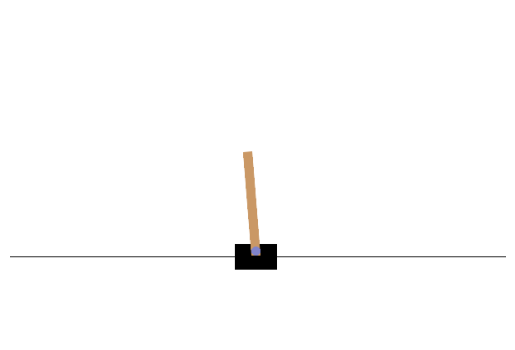

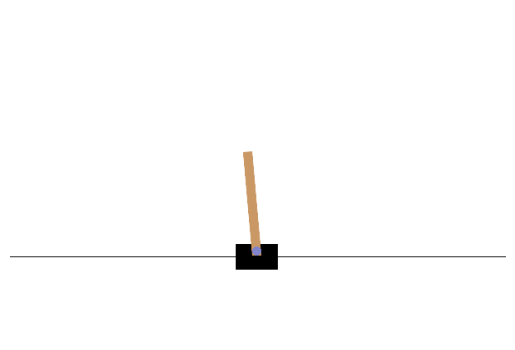

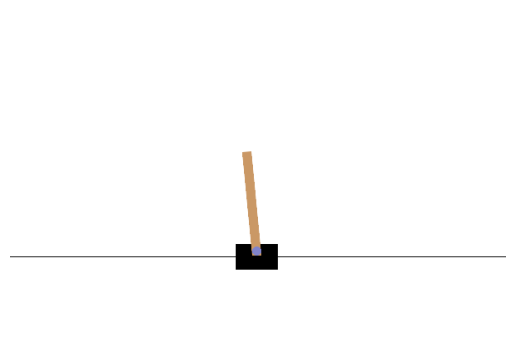

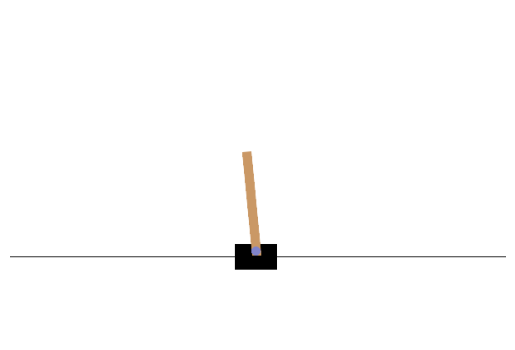

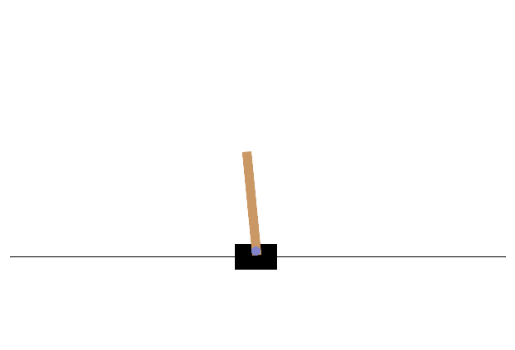

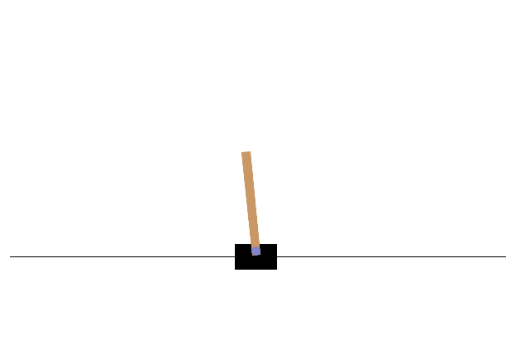

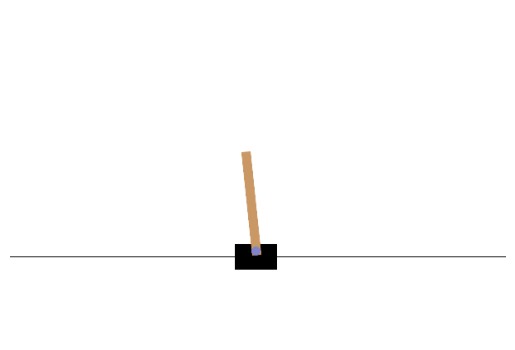

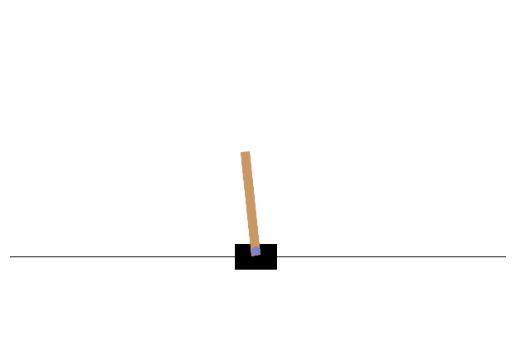

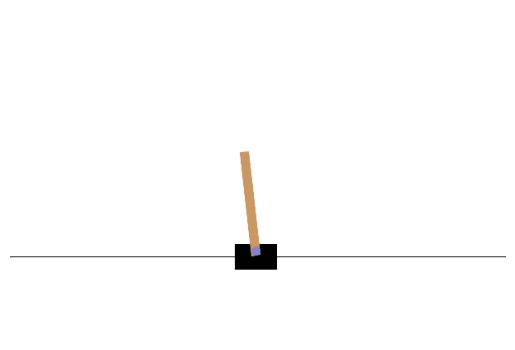

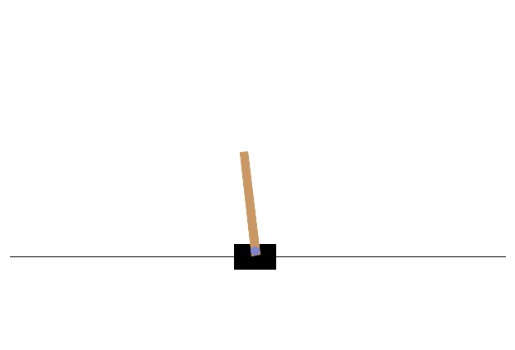

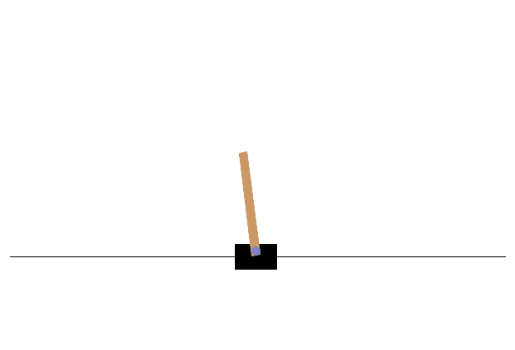

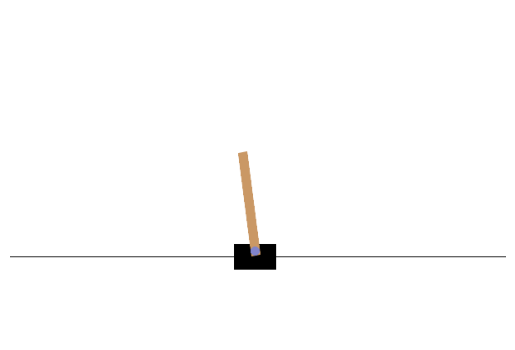

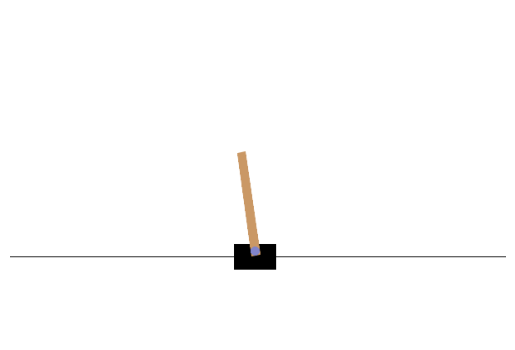

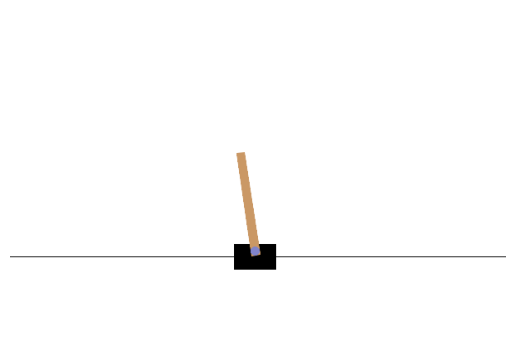

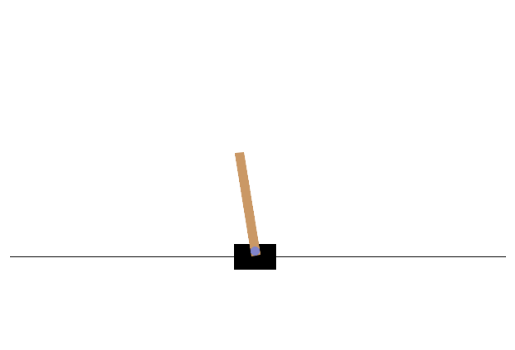

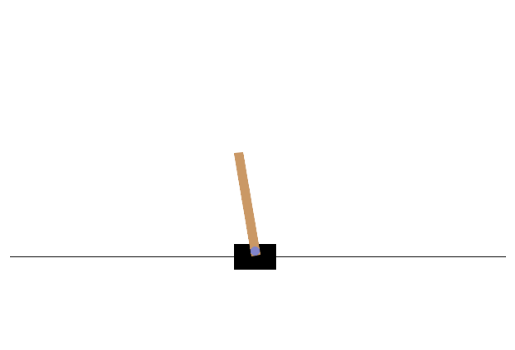

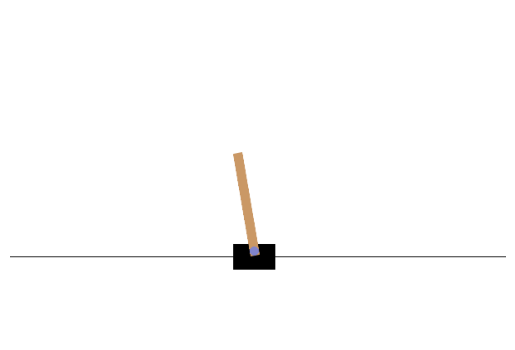

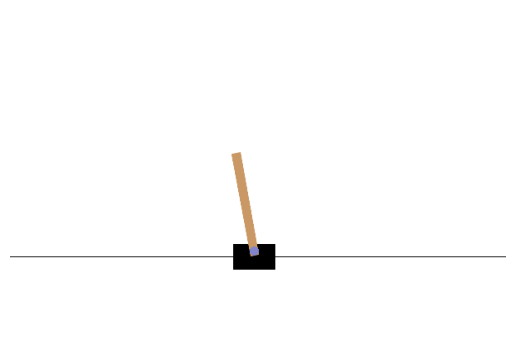

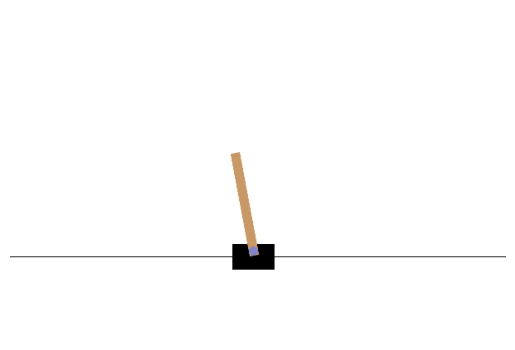

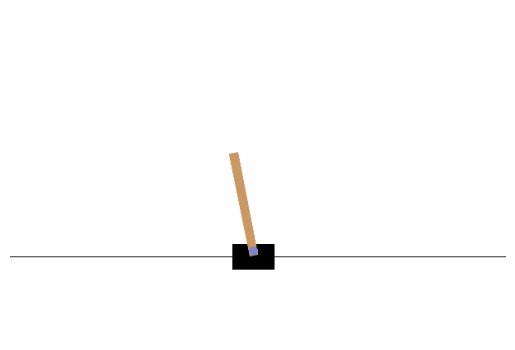

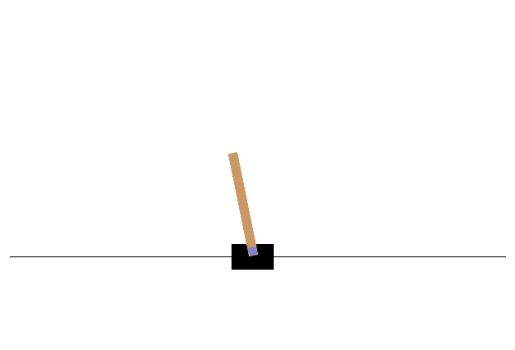

<Figure size 640x480 with 0 Axes>

In [2]:
import matplotlib.pyplot as plt
import time

env = gym.make("CartPole-v1", render_mode="rgb_array")

plt.figure()

for episode in range(5):

    state, _ = env.reset()
    state = tf.convert_to_tensor([state], dtype=tf.float32)

    done = False

    while not done:

        frame = env.render()

        plt.imshow(frame)
        plt.axis("off")
        plt.pause(0.03)
        plt.clf()

        action = tf.argmax(q_net(state)[0]).numpy()

        next_state, reward, terminated, truncated, _ = env.step(action)

        done = terminated or truncated

        state = tf.convert_to_tensor([next_state], dtype=tf.float32)

env.close()